# Preliminaries

In [ ]:
!pip install iterative-stratification

In [ ]:
import csv
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import torch.nn.functional as F
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
import time
from datetime import datetime
from collections import Counter, defaultdict
import random
import matplotlib.pyplot as plt
import json
import pandas as pd
from scipy.spatial.distance import cosine

print(MultilabelStratifiedKFold)
print(type(MultilabelStratifiedKFold))
print("CUDA available:", torch.cuda.is_available())
print("GPU device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

<class 'iterstrat.ml_stratifiers.MultilabelStratifiedKFold'>
<class 'abc.ABCMeta'>
CUDA available: True
GPU device: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Needed functions and defenitions

In [ ]:
def load_masked_multilabel_dataset(csv_path, num_labels=122):
    sequences = []
    targets = []
    masks = []
    label_counter = Counter()

    with open(csv_path, newline='') as file:
        reader = csv.DictReader(file)
        for row in reader:
            seq_vector = [int(bit) for bit in row["sequence"]]
            raw_labels = row["labels"].split(";")

            # Initialize target and mask
            target = np.zeros(num_labels, dtype=np.float32)
            mask = np.zeros(num_labels, dtype=np.float32)

            for label_str in raw_labels:
                label = int(label_str)
                abs_label = abs(label)

                if abs_label < 1 or abs_label > num_labels:
                    continue  # skip out-of-range

                index = abs_label - 1  # map label 1-122 → index 0-121

                if label > 0:
                    target[index] = 1
                    mask[index] = 1
                elif label < 0:
                    target[index] = 0
                    mask[index] = 1

                label_counter[index] += 1

            sequences.append(seq_vector)
            targets.append(target)
            masks.append(mask)

    label_counts = [label_counter.get(i, 0) for i in range(num_labels)]

    return np.array(sequences, dtype=np.uint8), np.array(targets), np.array(masks), label_counts


In [ ]:
class MaskedMultilabelDataset(Dataset):
    def __init__(self, sequences, targets, masks):
        self.sequences = sequences.reshape(-1, 500, 4).astype(np.float32)
        self.targets = targets.astype(np.float32)
        self.masks = masks.astype(np.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.float32)
        y = torch.tensor(self.targets[idx], dtype=torch.float32)
        m = torch.tensor(self.masks[idx], dtype=torch.float32)
        return x, y, m

In [ ]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, pool=True):
        super().__init__()
        self.pool = pool
        self.same_channels = (in_channels == out_channels)

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2)
        self.bn2 = nn.BatchNorm1d(out_channels)

        if not self.same_channels:
            self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual = nn.Identity()

        self.pool_layer = nn.MaxPool1d(2) if pool else nn.Identity()

    def forward(self, x):
        identity = self.residual(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        out = self.relu(out)
        out = self.pool_layer(out)
        return out


class CNNMultiLabelResidual(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.encoder = nn.Sequential(
            ResidualBlock1D(4, 64, kernel_size=7, pool=True),     # [B, 64, 250]
            ResidualBlock1D(64, 128, kernel_size=7, pool=True),   # [B, 128, 125]
            ResidualBlock1D(128, 256, kernel_size=5, pool=True),  # [B, 256, ~62]
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 62, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_labels)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, 4, 500]
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [ ]:
def optimize_thresholds(y_true, y_probs, thresholds=np.linspace(0.1, 0.9, 9)):
    best_thresholds = []

    for i in range(y_true.shape[1]):
        best_f1 = 0
        best_t = 0.5

        for t in thresholds:
            preds = (y_probs[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        best_thresholds.append(best_t)

    return np.array(best_thresholds)

In [ ]:
def get_sorted_by_auc(aurocs, f1s, f1s_05, thresholds, confusions, avg_output_sums):
  # Get valid AUROC scores and sort
    indexed_aurocs = [(i, auc, f1, f1_05, threshold, confusion, avg_output_sum) for i, (auc, f1, f1_05, threshold, confusion, avg_output_sum) in enumerate(zip(aurocs, f1s, f1s_05, thresholds, confusions, avg_output_sums)) if not np.isnan(auc)]
    sorted_by_auc = sorted(indexed_aurocs, key=lambda x: x[1], reverse=True)

    return sorted_by_auc

In [ ]:
def masked_bce_with_soft_neg(outputs, targets, masks, lambda_unknown=1.0, lambda_pos=2.0):
    """
    - outputs: raw logits from the model [B, L]
    - targets: true labels (1 or 0) [B, L]
    - masks: 1 for known labels, 0 for unknowns [B, L]
    """
    # BCE loss per element
    bce = F.binary_cross_entropy_with_logits(outputs, targets, reduction='none')

    pos_weight = (targets == 1).float() * lambda_pos + (targets == 0).float()

    masked_loss = (pos_weight * bce * masks).sum() / masks.sum()

    # Encourage model to output low scores for unknown labels
    unknown_mask = (1 - masks).float()
    zero_targets = torch.zeros_like(targets)
    unknown_penalty = F.binary_cross_entropy_with_logits(outputs, zero_targets, reduction='none')
    unknown_penalty = (unknown_penalty * unknown_mask).sum() / unknown_mask.sum()


    return masked_loss + lambda_unknown * unknown_penalty


In [ ]:
def evaluate_masked(model, dataloader, device):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []

    with torch.no_grad():
        for batch_x, batch_y, batch_mask in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            batch_mask = batch_mask.to(device)

            outputs = model(batch_x)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_preds.append(probs)
            all_targets.append(batch_y.cpu().numpy())
            all_masks.append(batch_mask.cpu().numpy())

    y_true = np.vstack(all_targets)
    y_pred = np.vstack(all_preds)
    y_mask = np.vstack(all_masks)

    n_labels = y_true.shape[1]
    aurocs, f1s, f1s_05, thresholds, confusions = [], [], [], [], []
    avg_output_sums = []

    # Precompute per-sample sums across all labels once
    per_sample_sum = y_pred.sum(axis=1)  # [N]

    for i in range(n_labels):
        valid = y_mask[:, i].astype(bool)
        if valid.sum() == 0:
            aurocs.append(np.nan)
            f1s.append(np.nan)
            f1s_05.append(np.nan)
            thresholds.append(0.5)
            confusions.append((0, 0, 0, 0))
            avg_output_sums.append(np.nan)  # no valid samples for this label
            continue

        avg_output_sums.append(float(per_sample_sum[valid].mean()))

        y_t, y_p = y_true[valid, i], y_pred[valid, i]

        try:
            aurocs.append(roc_auc_score(y_t, y_p))
            precision, recall, thresh = precision_recall_curve(y_t, y_p)
            f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
            best_idx = np.nanargmax(f1_scores)
            best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5
            thresholds.append(best_thresh)

            y_pred_bin = (y_p >= best_thresh).astype(int)
            f1s.append(f1_score(y_t, y_pred_bin))

            y_pred_bin_05 = (y_p >= 0.5).astype(int)
            f1s_05.append(f1_score(y_t, y_pred_bin_05))


            TP = np.sum((y_t == 1) & (y_pred_bin == 1))
            FP = np.sum((y_t == 0) & (y_pred_bin == 1))
            FN = np.sum((y_t == 1) & (y_pred_bin == 0))
            TN = np.sum((y_t == 0) & (y_pred_bin == 0))
            confusions.append((TP, FP, FN, TN))
        except ValueError:
            aurocs.append(np.nan)
            f1s.append(np.nan)
            f1s_05.append(np.nan)
            thresholds.append(0.5)
            confusions.append((0, 0, 0, 0))

    mAP = average_precision_score(
        y_true[y_mask.astype(bool)],
        y_pred[y_mask.astype(bool)],
        average="macro"
    )

    return aurocs, f1s, f1s_05, mAP, thresholds, confusions, y_true, y_pred, y_mask, avg_output_sums


In [ ]:
def train(model, dataloader, criterion, optimizer, device, lambda_unknown=1.0, lambda_pos=2.0):
    model.train()
    total_loss = 0

    for batch_x, batch_y, batch_mask in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_mask = batch_mask.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)

        # Apply mask before loss
        loss = masked_bce_with_soft_neg(outputs, batch_y, batch_mask, lambda_unknown, lambda_pos)

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(dataloader.dataset)

In [ ]:
def plot_label_histogram_mask(label_id, y_true, y_pred, mask, threshold, title, scale=""):
    # Extract relevant values for this label
    y_t = y_true[:, label_id]
    y_p = y_pred[:, label_id]
    m = mask[:, label_id]

    # Filter only known labels
    known = m == 1
    y_t = y_t[known]
    y_p = y_p[known]

    pos_preds = y_p[y_t == 1]
    neg_preds = y_p[y_t == 0]

    plt.figure(figsize=(6, 4))
    plt.hist(neg_preds, bins=30, alpha=0.6, label="Negative", color="blue")
    plt.hist(pos_preds, bins=30, alpha=0.6, label="Positive", color="orange")

    plt.axvline(x=threshold, color='red', linestyle='--', label=f"Threshold = {threshold:.2f}")

    plt.title(f"{title} (Label {label_id+1})")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count (log)")
    if scale == "log":
      plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_all_label_histogram_masked(y_true, y_pred, mask, thresholds=None, bins=50, scale="log"):
    """
    Aggregate histogram over ALL labels (masked):
      - y_true, y_pred, mask: arrays of shape [N, L]
      - Only entries where mask==1 are used
      - thresholds:
          * None: no vertical line
          * scalar: draw one vertical line at that threshold
          * array-like (len L): draw median & mean threshold lines
      - scale: "" or "log" for y-axis
    """
    # Keep only known entries
    valid = (mask == 1)
    if not np.any(valid):
        raise ValueError("No known entries (mask==1).")

    y_t_known = y_true[valid].astype(np.int32)
    y_p_known = y_pred[valid].astype(np.float32)

    pos_preds = y_p_known[y_t_known == 1]
    neg_preds = y_p_known[y_t_known == 0]

    # Plot
    plt.figure(figsize=(7, 5))
    plt.hist(neg_preds, bins=bins, alpha=0.6, label=f"Negative (n={len(neg_preds)})", color="blue")
    plt.hist(pos_preds, bins=bins, alpha=0.6, label=f"Positive (n={len(pos_preds)})", color="orange")

    # Threshold handling
    if thresholds is not None:
        if np.isscalar(thresholds):
            thr = float(thresholds)
            plt.axvline(x=thr, color='red', linestyle='--', label=f"Threshold = {thr:.2f}")
        else:
            thr_arr = np.asarray(thresholds, dtype=float)
            thr_med = np.nanmedian(thr_arr)
            thr_mean = np.nanmean(thr_arr)
            plt.axvline(x=thr_med, color='red', linestyle='--', label=f"Median thr = {thr_med:.2f}")
            plt.axvline(x=thr_mean, color='green', linestyle='--', label=f"Mean thr = {thr_mean:.2f}")

    plt.title("Aggregated Prediction Histogram (all labels, masked)")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count" + (" (log)" if scale == "log" else ""))
    if scale == "log":
        plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_label_histogram(label_id, y_true, y_pred, threshold, title):
    pos_preds = y_pred[y_true == 1]
    neg_preds = y_pred[y_true == 0]

    plt.figure(figsize=(6, 4))
    plt.hist(neg_preds, bins=30, alpha=0.6, label="Negative", color="blue")
    plt.hist(pos_preds, bins=30, alpha=0.6, label="Positive", color="orange")

    # Plot threshold as vertical line
    plt.axvline(x=threshold, color='red', linestyle='--', label=f"Threshold = {threshold:.2f}")

    plt.title(f"{title} (Label {label_id})")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count (log)")
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
Class_mapping = {'AATF': 1, 'NEG_AATF': -1, 'ADAT1': 2, 'NEG_ADAT1': -2, 'AGGF1': 3, 'NEG_AGGF1': -3, 'AKAP1': 4, 'NEG_AKAP1': -4, 'AKAP8L': 5, 'NEG_AKAP8L': -5,
                 'APOBEC3C': 6, 'NEG_APOBEC3C': -6, 'AQR': 7, 'NEG_AQR': -7, 'BCCIP': 8, 'NEG_BCCIP': -8, 'BCLAF1': 9, 'NEG_BCLAF1': -9, 'BUD13': 10, 'NEG_BUD13': -10,
                 'CDC40': 11, 'NEG_CDC40': -11, 'CPSF6': 12, 'NEG_CPSF6': -12, 'CSTF2': 13, 'NEG_CSTF2': -13, 'CSTF2T': 14, 'NEG_CSTF2T': -14, 'DDX1': 15, 'NEG_DDX1': -15,
                 'DDX24': 16, 'NEG_DDX24': -16, 'DDX3X': 17, 'NEG_DDX3X': -17, 'DDX43': 18, 'NEG_DDX43': -18, 'DDX52': 19, 'NEG_DDX52': -19, 'DDX55': 20, 'NEG_DDX55': -20,
                 'DDX59': 21, 'NEG_DDX59': -21, 'DDX6': 22, 'NEG_DDX6': -22, 'DGCR8': 23, 'NEG_DGCR8': -23, 'DHX30': 24, 'NEG_DHX30': -24, 'DKC1': 25, 'NEG_DKC1': -25,
                 'DROSHA': 26, 'NEG_DROSHA': -26, 'EFTUD2': 27, 'NEG_EFTUD2': -27, 'EIF3D': 28, 'NEG_EIF3D': -28, 'EIF3H': 29, 'NEG_EIF3H': -29, 'EIF4E': 30, 'NEG_EIF4E': -30,
                 'EIF4G2': 31, 'NEG_EIF4G2': -31, 'ELAC2': 32, 'NEG_ELAC2': -32, 'ELAVL1': 33, 'NEG_ELAVL1': -33, 'EWSR1': 34, 'NEG_EWSR1': -34, 'EXOSC10': 35, 'NEG_EXOSC10': -35,
                 'EXOSC5': 36, 'NEG_EXOSC5': -36, 'FAM120A': 37, 'NEG_FAM120A': -37, 'FASTKD2': 38, 'NEG_FASTKD2': -38, 'FKBP4': 39, 'NEG_FKBP4': -39, 'FMR1': 40, 'NEG_FMR1': -40,
                 'FTO': 41, 'NEG_FTO': -41, 'FUBP3': 42, 'NEG_FUBP3': -42, 'FUS': 43, 'NEG_FUS': -43, 'FXR1': 44, 'NEG_FXR1': -44, 'FXR2': 45, 'NEG_FXR2': -45,
                 'G3BP1': 46, 'NEG_G3BP1': -46, 'GARS': 47, 'NEG_GARS': -47, 'GEMIN5': 48, 'NEG_GEMIN5': -48, 'GPKOW': 49, 'NEG_GPKOW': -49, 'GRSF1': 50, 'NEG_GRSF1': -50,
                 'GRWD1': 51, 'NEG_GRWD1': -51, 'GTF2F1': 52, 'NEG_GTF2F1': -52, 'HNRNPC': 53, 'NEG_HNRNPC': -53, 'HNRNPK': 54, 'NEG_HNRNPK': -54, 'HNRNPL': 55, 'NEG_HNRNPL': -55,
                 'HNRNPM': 56, 'NEG_HNRNPM': -56, 'IGF2BP1': 57, 'NEG_IGF2BP1': -57, 'IGF2BP2': 58, 'NEG_IGF2BP2': -58, 'IGF2BP3': 59, 'NEG_IGF2BP3': -59, 'ILF3': 60, 'NEG_ILF3': -60,
                 'KHDRBS1': 61, 'NEG_KHDRBS1': -61, 'KHSRP': 62, 'NEG_KHSRP': -62, 'LIN28B': 63, 'NEG_LIN28B': -63, 'LSM11': 64, 'NEG_LSM11': -64, 'MATR3': 65, 'NEG_MATR3': -65,
                 'MBNL1': 66, 'NEG_MBNL1': -66, 'METAP2': 67, 'NEG_METAP2': -67, 'MORC2': 68, 'NEG_MORC2': -68, 'MTPAP': 69, 'NEG_MTPAP': -69, 'NKRF': 70, 'NEG_NKRF': -70,
                 'NOLC1': 71, 'NEG_NOLC1': -71, 'NONO': 72, 'NEG_NONO': -72, 'PABPC4': 73, 'NEG_PABPC4': -73, 'PABPN1': 74, 'NEG_PABPN1': -74, 'PCBP1': 75, 'NEG_PCBP1': -75,
                 'PCBP2': 76, 'NEG_PCBP2': -76, 'PHF6': 77, 'NEG_PHF6': -77, 'PPIG': 78, 'NEG_PPIG': -78, 'PPIL4': 79, 'NEG_PPIL4': -79, 'PRPF4': 80, 'NEG_PRPF4': -80,
                 'PRPF8': 81, 'NEG_PRPF8': -81, 'PTBP1': 82, 'NEG_PTBP1': -82, 'PUM1': 83, 'NEG_PUM1': -83, 'PUM2': 84, 'NEG_PUM2': -84, 'QKI': 85, 'NEG_QKI': -85,
                 'RBFOX2': 86, 'NEG_RBFOX2': -86, 'RBM15': 87, 'NEG_RBM15': -87, 'RBM22': 88, 'NEG_RBM22': -88, 'RBM5': 89, 'NEG_RBM5': -89, 'RNF187': 90, 'NEG_RNF187': -90,
                 'RPS3': 91, 'NEG_RPS3': -91, 'RYBP': 92, 'NEG_RYBP': -92, 'SAFB': 93, 'NEG_SAFB': -93, 'SAFB2': 94, 'NEG_SAFB2': -94, 'SF3A3': 95, 'NEG_SF3A3': -95,
                 'SF3B4': 96, 'NEG_SF3B4': -96, 'SFPQ': 97, 'NEG_SFPQ': -97, 'SLTM': 98, 'NEG_SLTM': -98, 'SMNDC1': 99, 'NEG_SMNDC1': -99, 'SND1': 100, 'NEG_SND1': -100,
                 'SRSF1': 101, 'NEG_SRSF1': -101, 'SRSF7': 102, 'NEG_SRSF7': -102, 'STAU2': 103, 'NEG_STAU2': -103, 'SUB1': 104, 'NEG_SUB1': -104, 'SUGP2': 105, 'NEG_SUGP2': -105,
                 'TAF15': 106, 'NEG_TAF15': -106, 'TARDBP': 107, 'NEG_TARDBP': -107, 'TIA1': 108, 'NEG_TIA1': -108, 'TIAL1': 109, 'NEG_TIAL1': -109, 'TRA2A': 110, 'NEG_TRA2A': -110,
                 'U2AF1': 111, 'NEG_U2AF1': -111, 'U2AF2': 112, 'NEG_U2AF2': -112, 'UCHL5': 113, 'NEG_UCHL5': -113, 'UPF1': 114, 'NEG_UPF1': -114, 'XPO5': 115, 'NEG_XPO5': -115,
                 'XRCC6': 116, 'NEG_XRCC6': -116, 'XRN2': 117, 'NEG_XRN2': -117, 'YBX3': 118, 'NEG_YBX3': -118, 'YWHAG': 119, 'NEG_YWHAG': -119, 'ZC3H11A': 120, 'NEG_ZC3H11A': -120,
                 'ZNF622': 121, 'NEG_ZNF622': -121, 'ZNF800': 122, 'NEG_ZNF800': -122}

Index_mapping = {1: 'AATF', -1: 'NEG_AATF', 2: 'ADAT1', -2: 'NEG_ADAT1', 3: 'AGGF1', -3: 'NEG_AGGF1', 4: 'AKAP1', -4: 'NEG_AKAP1', 5: 'AKAP8L', -5: 'NEG_AKAP8L',
                 6: 'APOBEC3C', -6: 'NEG_APOBEC3C', 7: 'AQR', -7: 'NEG_AQR', 8: 'BCCIP', -8: 'NEG_BCCIP', 9: 'BCLAF1', -9: 'NEG_BCLAF1', 10: 'BUD13', -10: 'NEG_BUD13',
                 11: 'CDC40', -11: 'NEG_CDC40', 12: 'CPSF6', -12: 'NEG_CPSF6', 13: 'CSTF2', -13: 'NEG_CSTF2', 14: 'CSTF2T', -14: 'NEG_CSTF2T', 15: 'DDX1', -15: 'NEG_DDX1',
                 16: 'DDX24', -16: 'NEG_DDX24', 17: 'DDX3X', -17: 'NEG_DDX3X', 18: 'DDX43', -18: 'NEG_DDX43', 19: 'DDX52', -19: 'NEG_DDX52', 20: 'DDX55', -20: 'NEG_DDX55',
                 21: 'DDX59', -21: 'NEG_DDX59', 22: 'DDX6', -22: 'NEG_DDX6', 23: 'DGCR8', -23: 'NEG_DGCR8', 24: 'DHX30', -24: 'NEG_DHX30', 25: 'DKC1', -25: 'NEG_DKC1',
                 26: 'DROSHA', -26: 'NEG_DROSHA', 27: 'EFTUD2', -27: 'NEG_EFTUD2', 28: 'EIF3D', -28: 'NEG_EIF3D', 29: 'EIF3H', -29: 'NEG_EIF3H', 30: 'EIF4E', -30: 'NEG_EIF4E',
                 31: 'EIF4G2', -31: 'NEG_EIF4G2', 32: 'ELAC2', -32: 'NEG_ELAC2', 33: 'ELAVL1', -33: 'NEG_ELAVL1', 34: 'EWSR1', -34: 'NEG_EWSR1', 35: 'EXOSC10', -35: 'NEG_EXOSC10',
                 36: 'EXOSC5', -36: 'NEG_EXOSC5', 37: 'FAM120A', -37: 'NEG_FAM120A', 38: 'FASTKD2', -38: 'NEG_FASTKD2', 39: 'FKBP4', -39: 'NEG_FKBP4', 40: 'FMR1', -40: 'NEG_FMR1',
                 41: 'FTO', -41: 'NEG_FTO', 42: 'FUBP3', -42: 'NEG_FUBP3', 43: 'FUS', -43: 'NEG_FUS', 44: 'FXR1', -44: 'NEG_FXR1', 45: 'FXR2', -45: 'NEG_FXR2',
                 46: 'G3BP1', -46: 'NEG_G3BP1', 47: 'GARS', -47: 'NEG_GARS', 48: 'GEMIN5', -48: 'NEG_GEMIN5', 49: 'GPKOW', -49: 'NEG_GPKOW', 50: 'GRSF1', -50: 'NEG_GRSF1',
                 51: 'GRWD1', -51: 'NEG_GRWD1', 52: 'GTF2F1', -52: 'NEG_GTF2F1', 53: 'HNRNPC', -53: 'NEG_HNRNPC', 54: 'HNRNPK', -54: 'NEG_HNRNPK', 55: 'HNRNPL', -55: 'NEG_HNRNPL',
                 56: 'HNRNPM', -56: 'NEG_HNRNPM', 57: 'IGF2BP1', -57: 'NEG_IGF2BP1', 58: 'IGF2BP2', -58: 'NEG_IGF2BP2', 59: 'IGF2BP3', -59: 'NEG_IGF2BP3', 60: 'ILF3', -60: 'NEG_ILF3',
                 61: 'KHDRBS1', -61: 'NEG_KHDRBS1', 62: 'KHSRP', -62: 'NEG_KHSRP', 63: 'LIN28B', -63: 'NEG_LIN28B', 64: 'LSM11', -64: 'NEG_LSM11', 65: 'MATR3', -65: 'NEG_MATR3',
                 66: 'MBNL1', -66: 'NEG_MBNL1', 67: 'METAP2', -67: 'NEG_METAP2', 68: 'MORC2', -68: 'NEG_MORC2', 69: 'MTPAP', -69: 'NEG_MTPAP', 70: 'NKRF', -70: 'NEG_NKRF',
                 71: 'NOLC1', -71: 'NEG_NOLC1', 72: 'NONO', -72: 'NEG_NONO', 73: 'PABPC4', -73: 'NEG_PABPC4', 74: 'PABPN1', -74: 'NEG_PABPN1', 75: 'PCBP1', -75: 'NEG_PCBP1',
                 76: 'PCBP2', -76: 'NEG_PCBP2', 77: 'PHF6', -77: 'NEG_PHF6', 78: 'PPIG', -78: 'NEG_PPIG', 79: 'PPIL4', -79: 'NEG_PPIL4', 80: 'PRPF4', -80: 'NEG_PRPF4',
                 81: 'PRPF8', -81: 'NEG_PRPF8', 82: 'PTBP1', -82: 'NEG_PTBP1', 83: 'PUM1', -83: 'NEG_PUM1', 84: 'PUM2', -84: 'NEG_PUM2', 85: 'QKI', -85: 'NEG_QKI',
                 86: 'RBFOX2', -86: 'NEG_RBFOX2', 87: 'RBM15', -87: 'NEG_RBM15', 88: 'RBM22', -88: 'NEG_RBM22', 89: 'RBM5', -89: 'NEG_RBM5', 90: 'RNF187', -90: 'NEG_RNF187',
                 91: 'RPS3', -91: 'NEG_RPS3', 92: 'RYBP', -92: 'NEG_RYBP', 93: 'SAFB', -93: 'NEG_SAFB', 94: 'SAFB2', -94: 'NEG_SAFB2', 95: 'SF3A3', -95: 'NEG_SF3A3',
                 96: 'SF3B4', -96: 'NEG_SF3B4', 97: 'SFPQ', -97: 'NEG_SFPQ', 98: 'SLTM', -98: 'NEG_SLTM', 99: 'SMNDC1', -99: 'NEG_SMNDC1', 100: 'SND1', -100: 'NEG_SND1',
                 101: 'SRSF1', -101: 'NEG_SRSF1', 102: 'SRSF7', -102: 'NEG_SRSF7', 103: 'STAU2', -103: 'NEG_STAU2', 104: 'SUB1', -104: 'NEG_SUB1', 105: 'SUGP2', -105: 'NEG_SUGP2',
                 106: 'TAF15', -106: 'NEG_TAF15', 107: 'TARDBP', -107: 'NEG_TARDBP', 108: 'TIA1', -108: 'NEG_TIA1', 109: 'TIAL1', -109: 'NEG_TIAL1', 110: 'TRA2A', -110: 'NEG_TRA2A',
                 111: 'U2AF1', -111: 'NEG_U2AF1', 112: 'U2AF2', -112: 'NEG_U2AF2', 113: 'UCHL5', -113: 'NEG_UCHL5', 114: 'UPF1', -114: 'NEG_UPF1', 115: 'XPO5', -115: 'NEG_XPO5',
                 116: 'XRCC6', -116: 'NEG_XRCC6', 117: 'XRN2', -117: 'NEG_XRN2', 118: 'YBX3', -118: 'NEG_YBX3', 119: 'YWHAG', -119: 'NEG_YWHAG', 120: 'ZC3H11A', -120: 'NEG_ZC3H11A',
                 121: 'ZNF622', -121: 'NEG_ZNF622', 122: 'ZNF800', -122: 'NEG_ZNF800'}

Character_mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
Index_Character_mapping = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}

# Training

## dataset loading

In [ ]:
csv_path = "/content/drive/MyDrive/RBPmap_plus/dataset_K562_multilabel_with_NEGs.csv"
print("Loading CSV and preprocessing...")
sequences, targets, masks, label_counts = load_masked_multilabel_dataset(csv_path)
print(f"Loaded {len(sequences)} sequences.")

print("Creating dataset object...")
dataset = MaskedMultilabelDataset(sequences, targets, masks)

Loading CSV and preprocessing...
Loaded 361180 sequences.
Creating dataset object...


## Define train parameters

In [ ]:
num_epochs = 30
batch_size = 256
lr = 1e-3
kfolds = 5

lambda_unknown = 1
lambda_pos = 15

## Main train

In [ ]:
start_training = time.time()

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
skf = MultilabelStratifiedKFold(n_splits=kfolds, shuffle=True, random_state=42)

strat_labels = targets * masks  # use only known labels for stratification

for fold, (train_idx, val_idx) in enumerate(skf.split(sequences, strat_labels)):
    if fold > 0: #just want to see performance
      break;

    cur_train_idx, cur_val_idx = train_idx, val_idx
    print(f"\n--- Fold {fold+1}/{kfolds} ---")
    print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")

    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, num_workers=2, shuffle=True)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size, num_workers=2)

    print("Initializing model, loss, and optimizer...")
    model = CNNMultiLabelResidual(num_labels=targets.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        start_epoch = time.time()
        train_loss = train(model, train_loader, criterion, optimizer, device, lambda_unknown=lambda_unknown, lambda_pos=lambda_pos)
        train_time = time.time()
        aurocs, f1s, f1s_05, mAP, thresholds, confusions, y_true, y_pred, y_mask, avg_output_sums = evaluate_masked(model, val_loader, device)
        end_epoch = time.time()

        avg_auroc = np.nanmean(aurocs)
        avg_sum = np.nanmean(avg_output_sums)
        sorted_by_auc = get_sorted_by_auc(aurocs, f1s, f1s_05, thresholds, confusions, avg_output_sums)
        avg_f1_05 = np.nanmean(f1s_05)
        avg_f1 = np.nanmean(f1s)

        scheduler.step(avg_auroc)

        print(f"Loss: {train_loss:.4f} | AUROC: {avg_auroc:.4f} | F1: {avg_f1:.4f} | F1(0.5): {avg_f1_05:.4f} | mAP: {mAP:.4f} | AvgSum: {np.mean(avg_sum):.4f} | Train time: {train_time - start_epoch:.2f}s | Eval time: {end_epoch - train_time:.2f}s")
        print("Average threshold:", np.mean(thresholds))
        print("Thresholds (min/max):", np.min(thresholds), np.max(thresholds))
        print("[INFO] AUROC Top 10 proteins:")
        for idx, auc, f1, f1_05, threshold, confusion, avg_sum in sorted_by_auc[:10]:
            tp, fp, fn, tn = confusion
            print(f"Protein {Index_mapping[idx]} ({idx}): AUROC = {auc:.4f} | F1: {f1:.4f} | F1(0.5): {f1_05:.4f} | Threshold: {threshold:.4f} | TP: {tp:4} | FP: {fp:4} | FN: {fn:4} | TN: {tn:4} | AvgSum: {avg_sum:.2f}")
        print("[INFO] AUROC Bottom 10 proteins:")
        for idx, auc, f1, f1_05, threshold, confusion, avg_sum in sorted_by_auc[-10:]:
            tp, fp, fn, tn = confusion
            print(f"Protein {Index_mapping[idx]} ({idx}): AUROC = {auc:.4f} | F1: {f1:.4f} | F1(0.5): {f1_05:.4f} | Threshold: {threshold:.4f} | TP: {tp:4} | FP: {fp:4} | FN: {fn:4} | TN: {tn:4} | AvgSum: {avg_sum:.2f}")


end_training = time.time()
print(f"\nTraining complete in {end_training - start_training:.2f} seconds.")
split_dict = { "train_idx": cur_train_idx.tolist(), "val_idx": cur_val_idx.tolist() }

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = model.__class__.__name__
model_save_path = f"/content/drive/MyDrive/RBPmap_plus/Models/{model_name}_{timestamp}.pth"
split_save_path = f"/content/drive/MyDrive/RBPmap_plus/Models/data_split_{timestamp}.json"
torch.save(model.state_dict(), model_save_path)
with open(split_save_path, "w") as f:
    json.dump(split_dict, f)
print(f"Model saved to {model_save_path}")
print(f"Saved train/val split indices to: {split_save_path}")



--- Fold 1/5 ---
Train size: 288944, Val size: 72236
Initializing model, loss, and optimizer...

Epoch 1/30
Loss: 3.1640 | AUROC: 0.8666 | F1: 0.8306 | F1(0.5): 0.7882 | mAP: 0.8880 | AvgSum: 69.7001 | Train time: 93.43s | Eval time: 8.45s
Average threshold: 0.72434556
Thresholds (min/max): 0.23377995 0.9487494
[INFO] AUROC Top 10 proteins:
Protein EIF4G2 (31): AUROC = 0.9922 | F1: 0.9721 | F1(0.5): 0.9540 | Threshold: 0.7798 | TP:  383 | FP:    5 | FN:   17 | TN:  322 | AvgSum: 64.98
Protein MTPAP (69): AUROC = 0.9895 | F1: 0.9657 | F1(0.5): 0.9646 | Threshold: 0.5280 | TP:  394 | FP:   22 | FN:    6 | TN:  322 | AvgSum: 71.68
Protein AKAP1 (4): AUROC = 0.9877 | F1: 0.9629 | F1(0.5): 0.9595 | Threshold: 0.5767 | TP:  389 | FP:   19 | FN:   11 | TN:  313 | AvgSum: 68.77
Protein GARS (47): AUROC = 0.9871 | F1: 0.9558 | F1(0.5): 0.9476 | Threshold: 0.6679 | TP:  378 | FP:   13 | FN:   22 | TN:  329 | AvgSum: 66.96
Protein FASTKD2 (38): AUROC = 0.9871 | F1: 0.9567 | F1(0.5): 0.9551 | Thr

## Training evaluation

In [ ]:
mask = np.vstack([m.cpu().numpy() for _, _, m in val_loader])

for i in range(122):
    label_id = sorted_by_auc[i][0]
    print(label_id)
    plot_label_histogram_mask(label_id, y_true, y_pred, mask, thresholds[i], Index_mapping[label_id+1])

Output hidden; open in https://colab.research.google.com to view.

Plotting histogram for best label 31 and worst label 57


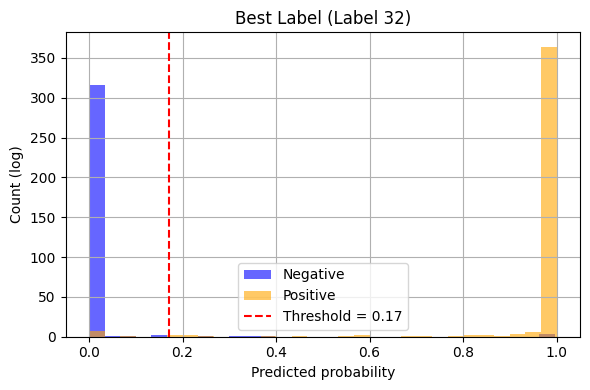

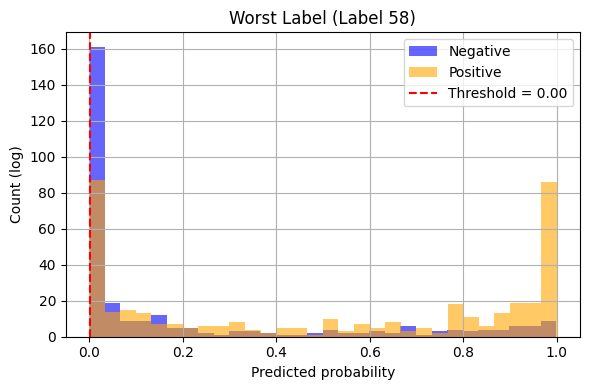

In [ ]:
best_label_id = sorted_by_auc[0][0]
worst_label_id = sorted_by_auc[-1][0]
# best_label_id = sorted_by_auc[1][0]
# worst_label_id = sorted_by_auc[-2][0]
# best_label_id = sorted_by_auc[2][0]
# worst_label_id = sorted_by_auc[-3][0]
# best_label_id = sorted_by_auc[3][0]
# worst_label_id = sorted_by_auc[-4][0]

print(f"Plotting histogram for best label {best_label_id} and worst label {worst_label_id}")
# plot_label_histogram(best_label_id, y_true[:, best_label_id], y_pred[:, best_label_id], thresholds[best_label_id], "Best Label")
# plot_label_histogram(worst_label_id, y_true[:, worst_label_id], y_pred[:, worst_label_id], thresholds[worst_label_id], "Worst Label")

mask = np.vstack([m.cpu().numpy() for _, _, m in val_loader])

plot_label_histogram_mask(best_label_id, y_true, y_pred, mask, thresholds[best_label_id], "Best Label")
plot_label_histogram_mask(worst_label_id, y_true, y_pred, mask, thresholds[worst_label_id], "Worst Label")


Plotting histogram for best label 31 and worst label 57


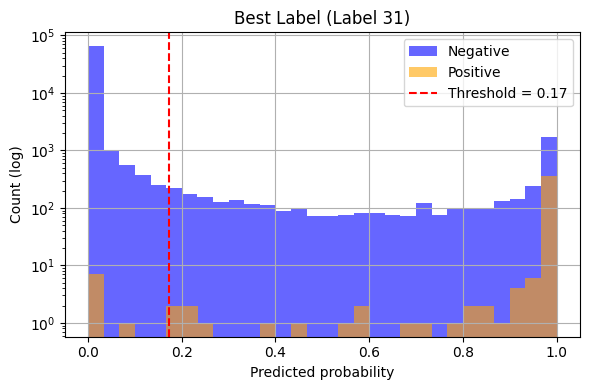

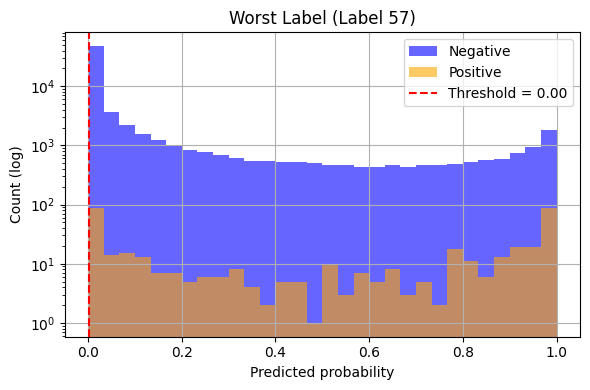

In [ ]:
best_label_id = sorted_by_auc[0][0]
worst_label_id = sorted_by_auc[-1][0]
# best_label_id = sorted_by_auc[1][0]
# worst_label_id = sorted_by_auc[-2][0]
# best_label_id = sorted_by_auc[2][0]
# worst_label_id = sorted_by_auc[-3][0]
# best_label_id = sorted_by_auc[3][0]
# worst_label_id = sorted_by_auc[-4][0]

print(f"Plotting histogram for best label {best_label_id} and worst label {worst_label_id}")
plot_label_histogram(best_label_id, y_true[:, best_label_id], y_pred[:, best_label_id], thresholds[best_label_id], "Best Label")
plot_label_histogram(worst_label_id, y_true[:, worst_label_id], y_pred[:, worst_label_id], thresholds[worst_label_id], "Worst Label")


# Evaluating (no need to train)

## Functions and definitions

In [ ]:
def predict_top_k_bindings(model, sequence_vector, k=10, device="cpu"):
    """
    Predicts the top-k most likely binding proteins for a single input sequence.

    Parameters:
        model: Trained PyTorch model
        sequence_vector: np.array shape (500, 4) or (2000,) or (2000, 1)
        k: number of top predictions to return
        device: device to run inference on

    Returns:
        List of tuples: (protein_index, probability), sorted by highest probability
    """

    model.eval()

    # Make sure shape is (1, 500, 4)
    if sequence_vector.ndim == 1:
        sequence_vector = sequence_vector.reshape(500, 4)
    elif sequence_vector.shape == (2000,):
        sequence_vector = sequence_vector.reshape(500, 4)
    elif sequence_vector.shape == (2000, 1):
        sequence_vector = sequence_vector.reshape(500, 4)

    # Convert to tensor
    sequence_tensor = torch.tensor(sequence_vector, dtype=torch.float32).unsqueeze(0).to(device)  # shape: [1, 500, 4]

    # Predict
    with torch.no_grad():
        logits = model(sequence_tensor)
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()  # shape: [num_labels]

    # Get top-k
    top_k_indices = np.argsort(probs)[::-1][:k]
    top_k_probs = probs[top_k_indices]

    return list(zip(top_k_indices, top_k_probs))


In [ ]:
def plot_binding_predictions_bar(top_bindings, label_tensor, mask_tensor, threshold=0.5, show_line=False, cluster_dict=None):
    label_tensor = np.array(label_tensor)
    mask_tensor = np.array(mask_tensor)

    pred_dict = {int(idx): float(prob) for idx, prob in top_bindings}

    for i in range(len(label_tensor)):
        if mask_tensor[i] == 1 and i not in pred_dict:
            pred_dict[i] = 0.0

    filtered = [(idx, prob) for idx, prob in pred_dict.items()
                if prob >= threshold or mask_tensor[idx] == 1]

    filtered_sorted = sorted(filtered, key=lambda x: x[1], reverse=True)
    indices = [idx for idx, _ in filtered_sorted]
    probs = [prob for _, prob in filtered_sorted]

    colors = []
    for idx in indices:
        if mask_tensor[idx] == 1:
            if label_tensor[idx] == 1:
                colors.append('blue')  # known binder
            else:
                colors.append('red')   # known non-binder
        else:
            colors.append('gray')      # unknown

    labels = [Index_mapping.get(idx + 1, str(idx + 1)) for idx in indices]

    label_to_cluster = {}
    if cluster_dict is not None:
        for cluster_name, info in cluster_dict.items():
            cluster_id = cluster_name.replace("cluster", "C")
            for protein in info["proteins"]:
                label_to_cluster[protein] = cluster_id

    plt.figure(figsize=(8, max(4, 0.4 * len(labels))))
    y_pos = np.arange(len(labels))
    plt.barh(y_pos, probs, color=colors)
    plt.yticks(y_pos, labels)
    plt.xlabel("Predicted Probability")
    plt.xlim(0, 1.0)
    if show_line:
        plt.axvline(threshold, color='black', linestyle='--', linewidth=1.5)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    if cluster_dict is not None:
        ax = plt.gca()
        for i, label in enumerate(labels):
            cluster_id = label_to_cluster.get(label, None)
            if cluster_id and probs[i] >= 0.2:
                ax.text(0.01, i, cluster_id, va='center', ha='left',
                        fontsize=8, color='black', fontweight='bold')

    plt.tight_layout()
    plt.show()


In [ ]:
@torch.no_grad()
def binding_rate_per_label(model, dataloader, device="cuda", threshold=0.5, return_counts=False):
    """
    For each label l:
      - rates[l]         = fraction of sequences predicted positive (>= threshold)  [over ALL sequences in loader]
      - success_ratio[l] = (# predicted positive among KNOWN entries) / (# ground-truth positives among KNOWN entries)

    If the dataloader yields (x, y, mask), we use y & mask to compute success_ratio.
    If it yields only x, success_ratio will be NaN (no labels to compare against).

    Returns:
        (rates, success_ratio)                             if return_counts == False
        (rates, success_ratio, total_num_sequences)        if return_counts == True
    """
    model.eval()
    sum_pred_all = None     # predicted positives over all sequences (for 'rates')
    total = 0

    # For success_ratio:
    sum_pred_known = None   # predicted positives among KNOWN entries (mask==1)
    sum_gt_pos = None       # ground-truth positives among KNOWN entries

    for batch in dataloader:
        if isinstance(batch, (list, tuple)):
            if len(batch) == 3:
                batch_x, batch_y, batch_mask = batch
            elif len(batch) == 2:
                batch_x, batch_y = batch
                batch_mask = None
            else:
                batch_x = batch[0]
                batch_y = None
                batch_mask = None
        else:
            batch_x = batch
            batch_y = None
            batch_mask = None

        batch_x = batch_x.to(device, non_blocking=True)

        logits = model(batch_x)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).to(torch.int64)  # [B, L]

        # For 'rates': predicted positives across all sequences
        pred_sum = preds.sum(dim=0).cpu().numpy().astype(np.int64)

        if sum_pred_all is None:
            sum_pred_all = pred_sum
        else:
            sum_pred_all += pred_sum

        total += preds.size(0)

        # For 'success_ratio': needs labels & mask
        if batch_y is not None:
            batch_y = batch_y.to(device, non_blocking=True)
            if batch_mask is not None:
                batch_mask = batch_mask.to(device, non_blocking=True).to(torch.int64)
                # count only KNOWN entries
                pred_known = ((preds == 1) & (batch_y == 1) & (batch_mask == 1)).sum(dim=0).cpu().numpy().astype(np.int64) #(TP)/(GT)
                gt_pos = (batch_y.to(torch.int64) * batch_mask).sum(dim=0).cpu().numpy().astype(np.int64)
            else:
                # if no mask, treat all as known
                pred_known = ((preds == 1) & (batch_y == 1)).sum(dim=0).cpu().numpy().astype(np.int64) #(TP)/(GT)
                gt_pos = (batch_y.to(torch.int64)).sum(dim=0).cpu().numpy().astype(np.int64)

            if sum_pred_known is None:
                sum_pred_known = pred_known
                sum_gt_pos = gt_pos
            else:
                sum_pred_known += pred_known
                sum_gt_pos += gt_pos

    # rates over all sequences
    if total > 0:
        rates = sum_pred_all / float(total)
    else:
        rates = np.zeros_like(sum_pred_all, dtype=np.float32)

    # success_ratio over known entries
    if sum_pred_known is not None and sum_gt_pos is not None:
        denom = np.where(sum_gt_pos > 0, sum_gt_pos, np.nan)  # avoid /0 → NaN
        success_ratio = sum_pred_known / denom
    else:
        # no labels available from loader
        success_ratio = np.full_like(rates, np.nan, dtype=np.float32)

    if return_counts:
        return rates, success_ratio, total
    return rates, success_ratio


## Loading model and dataset

In [ ]:
load_option = "from_path" # "from_path" / "from_train"
loaded_batch_size = 256
time_stamp = "20250812_123241"

if load_option == "from_path":
    #load dataset
    csv_path = "/content/drive/MyDrive/RBPmap_plus/dataset_K562_multilabel_with_NEGs.csv"
    print("Loading CSV and preprocessing...")
    sequences, targets, masks, label_counts = load_masked_multilabel_dataset(csv_path)
    print(f"Loaded {len(sequences)} sequences.")

    dataset = MaskedMultilabelDataset(sequences, targets, masks)

    # Load indices
    split_load_path = f"/content/drive/MyDrive/RBPmap_plus/Models/data_split_{time_stamp}.json"
    with open(split_load_path, "r") as f:
        split_dict = json.load(f)

    loaded_train_idx = split_dict["train_idx"]
    loaded_val_idx = split_dict["val_idx"]

    print(f"Loaded {len(loaded_train_idx)} train sequences.")
    print(f"Loaded {len(loaded_val_idx)} validation sequences.")

    loaded_train_loader = DataLoader(Subset(dataset, loaded_train_idx), batch_size=loaded_batch_size, num_workers=2, shuffle=True)
    loaded_val_loader = DataLoader(Subset(dataset, loaded_val_idx), batch_size=loaded_batch_size, num_workers=2)

    loaded_model = CNNMultiLabelResidual(num_labels=targets.shape[1])
    model_load_path = f"/content/drive/MyDrive/RBPmap_plus/Models/CNNMultiLabelResidual_{time_stamp}.pth"
    loaded_model.load_state_dict(torch.load(model_load_path, map_location=device))
    loaded_model.to(device)

elif load_option == "from_train":
    loaded_train_loader = train_loader
    loaded_val_loader = val_loader
    loaded_model = model
    loaded_model.to(device)


Loading CSV and preprocessing...
Loaded 361180 sequences.


## Main evaluate

In [ ]:
def find_indices_with_label(dataset, label_index, max_results=20):
    results = []
    for i in range(len(dataset)):
        seq, label, mask = dataset[i]
        if mask[label_index] == 1 and label[label_index] == 1:
            results.append(i)
            if len(results) >= max_results:
                break
    return results

def find_indices_with_multilabel(dataset, max_results=20):
    results = []
    for i in range(len(dataset)):
        seq, label, mask = dataset[i]
        if sum(label) > 1:
            results.append(i)
            if len(results) >= max_results:
                break
    return results

prot = "IGF2BP2"
label_idx = Class_mapping[prot] - 1  # your label index
positive_indices = find_indices_with_label(loaded_val_loader.dataset, label_idx)
print(positive_indices)

multilabel_indices = find_indices_with_multilabel(loaded_val_loader.dataset)
print(multilabel_indices)

[105, 370, 383, 391, 617, 695, 989, 1128, 1185, 1190, 1414, 1455, 2157, 2214, 2359, 2459, 2522, 2555, 2586, 2822]
[0, 36, 55, 77, 105, 176, 293, 296, 302, 306, 375, 426, 487, 514, 515, 520, 555, 557, 559, 562]


Decoded sequence (50 bases per line):
GGTTCTGAGTCTGCAGGGAAAAAAAGCACATGAGTTTATCAGTTGAAGAA
AAAAGCAAATAATGCAATAAATTATATGTACTTTTTCAAAACATTTACCA
GGACTTCACACTCAAGCATTTTTTCCTACTCAATCATAATTCCCCTTTCT
TAATGTTTCACATTTGCGGGGCGAGGGGCACAAAAAACACTAGAAATGAC
CAAATACGAAAACCTTCATGGTTCTGGTTGCCTTCTAAAACCTACCTGTG
GGATAGCTGCCATGAAGTAACCTGAAGGAGGTGCTGGCTGGTAGGGGTTG
ATTACAGGGTTGGGAACAGCTCGTACACTTGCCATTCTCTGCATATACTG
GTTAGTGAGGTGAGCCTGGCGCTCTTCTTTGCGCTGAGCTAAAGCTACAT
ACAATGGCTTTGTGGCCACAATTCTACCGTTCATTTCTGTAACTGCTTTA
GTGGCTTCTTCTGGGGAGGAGAAACATACAAAACCAAACCCTTTGCTGCG

Known binding proteins (+): ['IGF2BP2 (58)', 'IGF2BP3 (59)']
Known non-binding proteins (−): None

Model predictions:


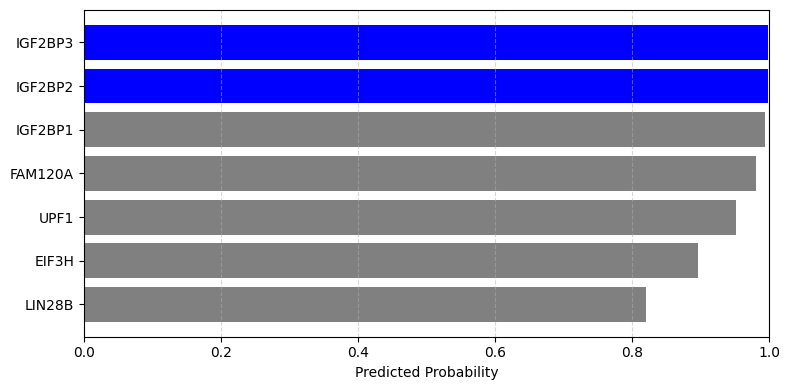

In [ ]:
random_idx = 105
# random_idx = random.randint(0, len(loaded_val_loader.dataset) - 1)
sequence_tensor, label_tensor, mask_tensor = loaded_val_loader.dataset[random_idx]
sequence_vector = sequence_tensor.numpy()  # shape: (500, 4)

top_bindings = predict_top_k_bindings(loaded_model, sequence_vector, k=122, device=device)

decoded_sequence = ""
for base in sequence_tensor:  # shape: (500, 4)
    idx = base.argmax().item()  # Find which nucleotide is '1'
    decoded_sequence += Index_Character_mapping.get(idx, 'N')  # Use 'N' if invalid

print("Decoded sequence (50 bases per line):")
for i in range(0, len(decoded_sequence), 50):
    print(decoded_sequence[i:i+50])

# Extract labels
positive_labels = [i+1 for i in range(len(label_tensor)) if mask_tensor[i] == 1 and label_tensor[i] == 1]
negative_labels = [i+1 for i in range(len(label_tensor)) if mask_tensor[i] == 1 and label_tensor[i] == 0]

# Print binding/non-binding labels
print("\nKnown binding proteins (+):", [f"{Index_mapping[j]} ({j})" for j in positive_labels] if positive_labels else "None")
print("Known non-binding proteins (−):", [f"{Index_mapping[j]} ({j})" for j in negative_labels] if negative_labels else "None")

print("\nModel predictions:")
plot_binding_predictions_bar(top_bindings, label_tensor.numpy(), mask_tensor.numpy(), threshold=0.8, show_line=False, cluster_dict=None)
# plot_binding_predictions_bar(top_bindings, label_tensor.numpy(), mask_tensor.numpy(), threshold=0.8, show_line=False, cluster_dict=cluster_dict)


In [ ]:
loaded_aurocs, loaded_f1s, loaded_f1s_05, loaded_mAP, loaded_thresholds, loaded_confusions, loaded_y_true, loaded_y_pred, loaded_y_mask, loaded_avg_output_sums = evaluate_masked(loaded_model, loaded_val_loader, device)

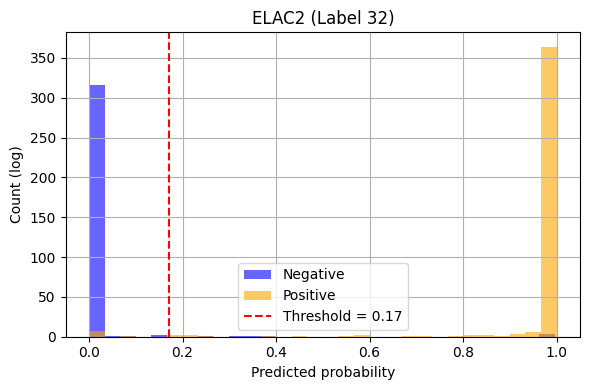

In [ ]:
loaded_mask = np.vstack([m.cpu().numpy() for _, _, m in loaded_val_loader])
label_id = 32 - 1 # pay attention to do "real" label minus 1
plot_label_histogram_mask(label_id, loaded_y_true, loaded_y_pred, loaded_mask, loaded_thresholds[label_id], Index_mapping[label_id+1])

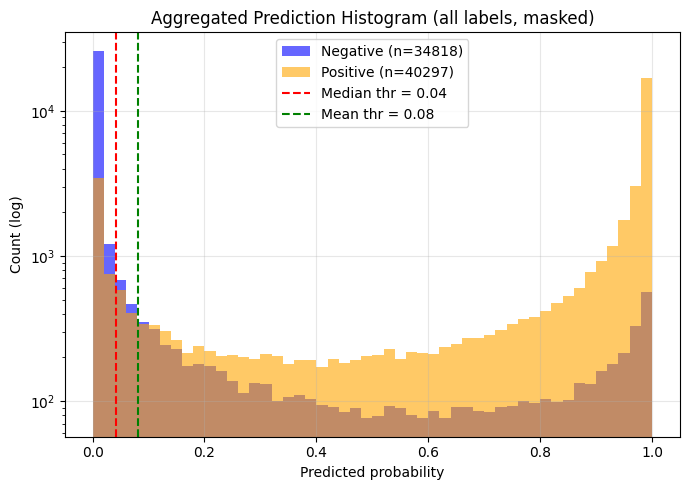

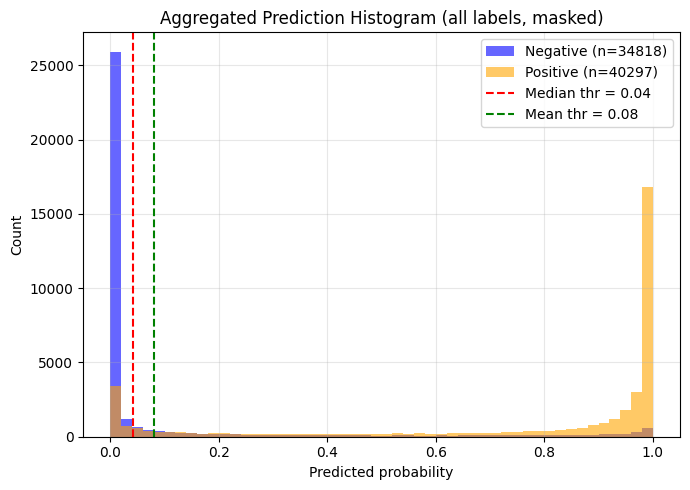

In [ ]:
# Using your loaded arrays (shape [N,L]):
plot_all_label_histogram_masked(
    loaded_y_true, loaded_y_pred, loaded_mask,
    thresholds=loaded_thresholds,
    bins=50, scale="log"
)

plot_all_label_histogram_masked(
    loaded_y_true, loaded_y_pred, loaded_mask,
    thresholds=loaded_thresholds,
    bins=50, scale=None
)

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_curves(y_true, y_pred, label_names=None, mask=None, num_prots=10):
    """
    Plots ROC curves for a selected subset of proteins based on AUC ranking.
    Only the average AUC is shown in the legend.

    Args:
        y_true (ndarray): True binary labels.
        y_pred (ndarray): Predicted probabilities.
        label_names (list): Optional list of protein names.
        mask (ndarray): Optional mask for valid values.
        num_prots (int): Number of proteins to display in plot. Default is 5.

    Returns:
        auc_dict: {label_name: auc_value or None}
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc

    num_labels = y_true.shape[1]
    auc_dict = {}
    roc_data = {}

    # Compute ROC and AUC for all labels
    for i in range(num_labels):
        if mask is not None:
            valid = mask[:, i].astype(bool)
            if not np.any(valid):
                auc_dict[label_names[i] if label_names else f"Label {i}"] = None
                continue
            y_t = y_true[valid, i]
            y_p = y_pred[valid, i]
        else:
            y_t = y_true[:, i]
            y_p = y_pred[:, i]

        label = label_names[i] if label_names else f"Label {i}"

        if np.unique(y_t).size < 2:
            auc_dict[label] = None
            continue

        fpr, tpr, _ = roc_curve(y_t, y_p)
        roc_auc = auc(fpr, tpr)
        auc_dict[label] = roc_auc
        roc_data[label] = (fpr, tpr)

    # Select which labels to plot
    valid_roc = [(label, auc) for label, auc in auc_dict.items() if auc is not None]
    sorted_roc = sorted(valid_roc, key=lambda x: x[1], reverse=True)

    if num_prots >= len(sorted_roc):
        selected = [label for label, _ in sorted_roc]
    else:
        step = max(1, len(sorted_roc) // (num_prots - 1))
        selected = [sorted_roc[0][0]]  # top AUC
        selected += [sorted_roc[i][0] for i in range(step, len(sorted_roc), step)][:num_prots - 1]

    # Plot
    plt.figure(figsize=(12, 10))
    for label in selected:
        fpr, tpr = roc_data[label]
        plt.plot(fpr, tpr, lw=1.5, label=f"{label} (AUC = {auc_dict[label]:.2f})")

    # Average AUC
    valid_aucs = [v for v in auc_dict.values() if v is not None]
    avg_auc = np.mean(valid_aucs) if valid_aucs else 0.0
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random chance")
    plt.legend(title=f"Avg AUC = {avg_auc:.3f}", loc="lower right", fontsize='medium')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves for Selected Labels")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return auc_dict


def plot_sorted_auc_histogram(auc_dict, lines=None, title="Sorted AUC Histogram",
                              xlabels=False, left_color="powderblue", right_color="red", threshold_color=0.8):
    """
    Plots a sorted histogram of AUC values with threshold-based coloring and dynamic legend.

    Parameters:
        auc_dict (dict): Mapping from protein/label names to AUC scores.
        lines (list of tuples): Horizontal lines to draw (e.g. [(0.5, "red"), (0.9, "blue")]).
        title (str): Plot title.
        xlabels (bool): Whether to show protein names as x-axis labels.
        left_color (str): Color for bars below the threshold.
        right_color (str): Color for bars above or equal to the threshold.
        threshold_color (float): AUC value that separates left_color and right_color bars.
    """
    # Filter and sort valid AUC values
    filtered_items = [(k, v) for k, v in auc_dict.items() if v is not None and not np.isnan(v)]
    sorted_items = sorted(filtered_items, key=lambda x: x[1])
    labels, auc_values = zip(*sorted_items)
    auc_values = np.array(auc_values)

    # Color bars based on threshold
    bar_colors = [right_color if val >= threshold_color else left_color for val in auc_values]

    # Plot
    plt.figure(figsize=(max(12, len(labels)*0.15), max(4, len(labels)*0.05)))
    plt.bar(range(len(auc_values)), auc_values, color=bar_colors)

    # Optional horizontal lines with legend
    if lines:
        for line_val, line_col in lines:
            count = np.sum(auc_values >= line_val)
            total = len(auc_values)
            plt.axhline(line_val, linestyle='--', linewidth=2, color=line_col,
                        label=f"AUC ≥ {line_val:.2f}: {count} / {total}")

    # X-axis labels
    if xlabels:
        plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
    else:
        plt.xticks([])

    # Axis and title
    plt.ylim(0.0, 1.0)
    # plt.xlabel("Labels")
    plt.ylabel("AUC Score")
    # plt.title(title)
    # if lines:
    #     plt.legend(facecolor='white', edgecolor='black', framealpha=1.0)

    plt.tight_layout()
    plt.show()



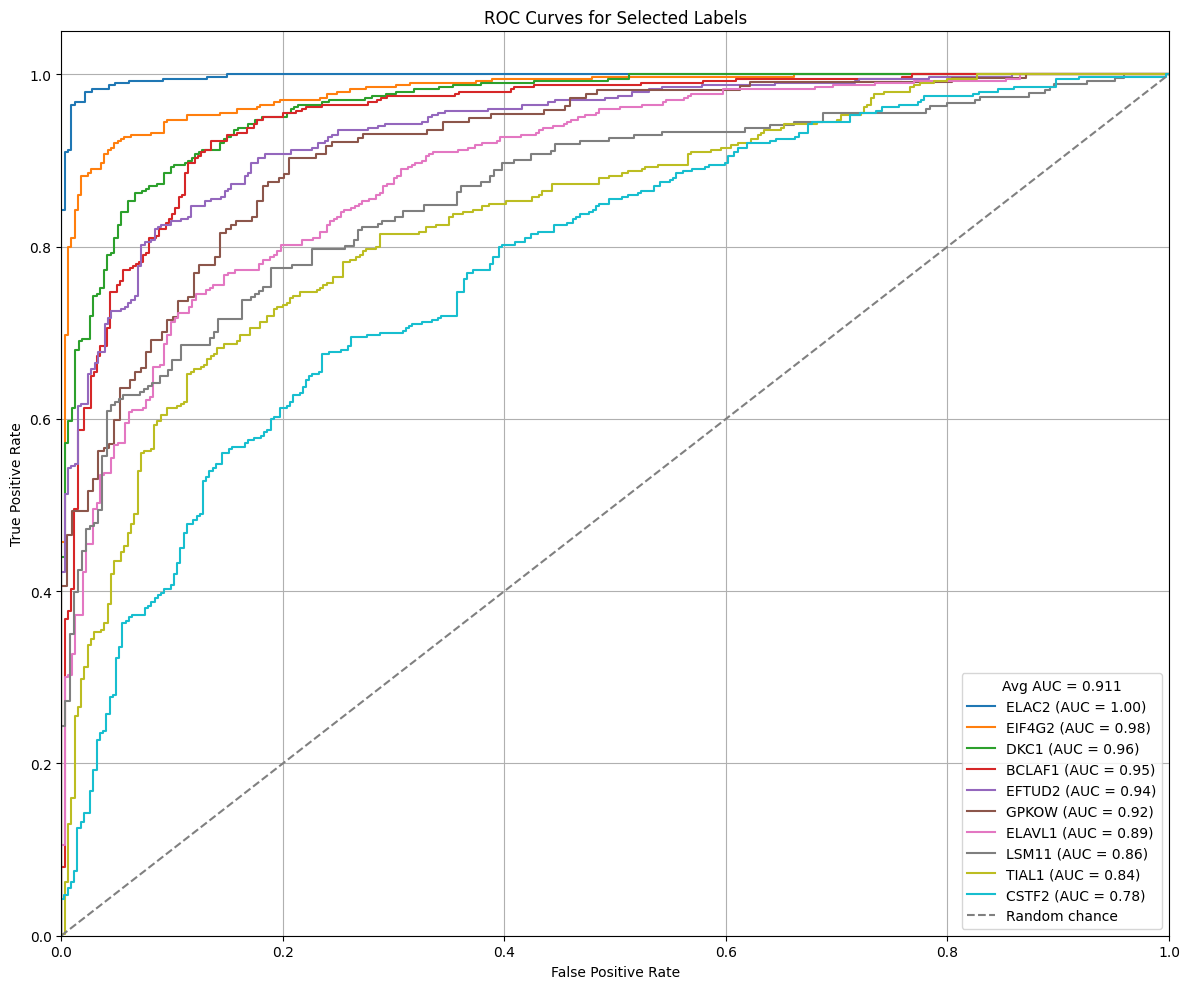

In [ ]:
protein_names = [Index_mapping.get(i+1, str(i+1)) for i in range(loaded_y_true.shape[1])]
auc_dict = plot_roc_curves(loaded_y_true, loaded_y_pred, label_names=protein_names, mask=loaded_y_mask, num_prots=10)

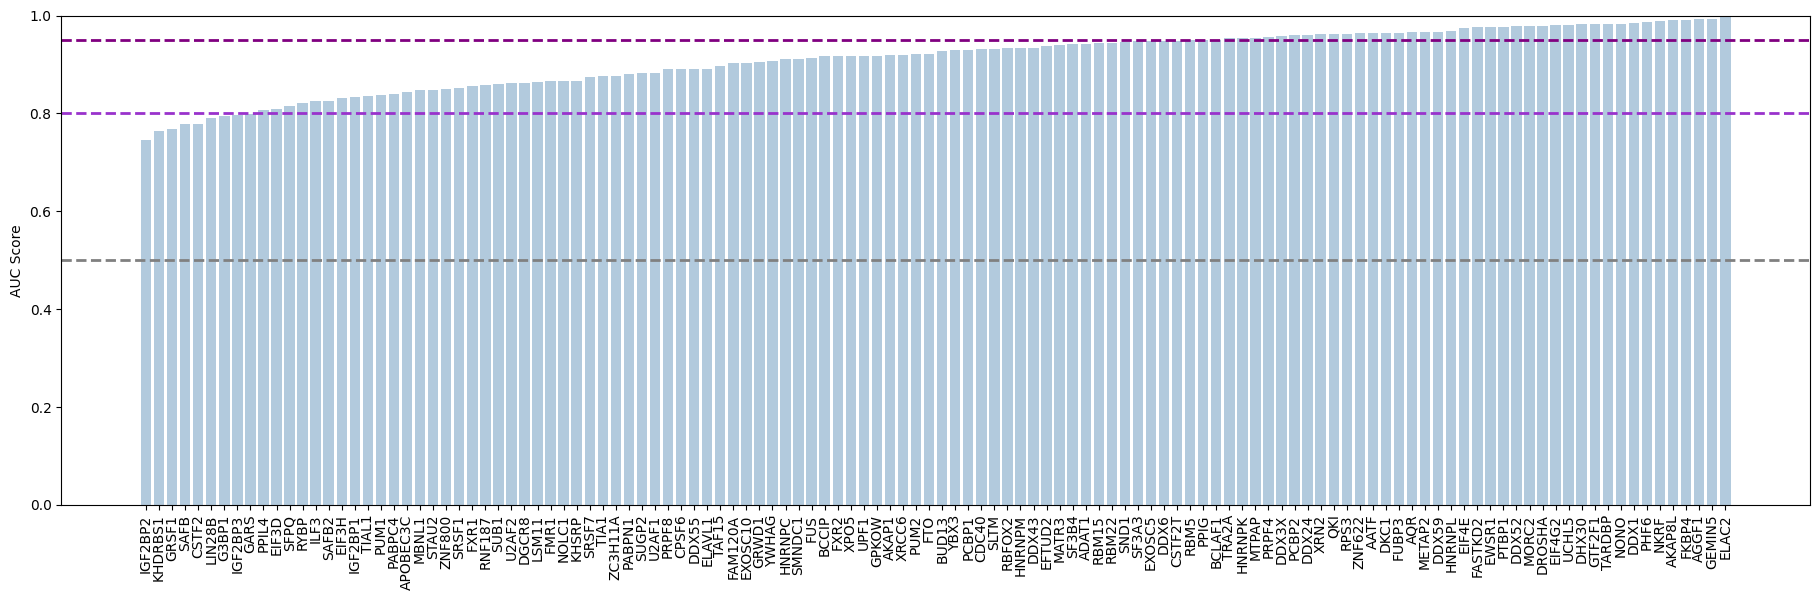

In [ ]:
lines=[(0.5, "gray"), (0.8, "darkorchid"), (0.95, "purple")]
# plot_sorted_auc_histogram(auc_dict, lines=lines, xlabels=True, left_color="#B2CADD", right_color="#4695d4", threshold_color=0.8)
# plot_sorted_auc_histogram(auc_dict, lines=lines, xlabels=True, left_color="#B2CADD", right_color="#2e76b0", threshold_color=0.95)
plot_sorted_auc_histogram(auc_dict, lines=lines, xlabels=True, left_color="#B2CADD", right_color="#2e76b0", threshold_color=1)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

def plot_precision_recall_curves(y_true, y_pred, label_names=None, mask=None):
    """
    Plot Precision-Recall (PR) curves for each label and return per-label AUC-PR scores.
    """
    n_labels = y_true.shape[1]
    avg_precisions = []

    plt.figure(figsize=(12, 10))
    for i in range(n_labels):
        if mask is not None:
            valid = mask[:, i].astype(bool)
            if not np.any(valid):
                avg_precisions.append(None)
                continue
            y_t = y_true[valid, i]
            y_p = y_pred[valid, i]
        else:
            y_t = y_true[:, i]
            y_p = y_pred[:, i]

        if np.sum(y_t) == 0:
            avg_precisions.append(None)
            continue

        precision, recall, _ = precision_recall_curve(y_t, y_p)
        ap = average_precision_score(y_t, y_p)
        avg_precisions.append(ap)
        plt.plot(recall, precision, alpha=0.4)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves per Label")
    plt.grid(True)

    mean_ap = np.mean([ap for ap in avg_precisions if ap is not None])
    plt.legend([f"Avg AUC-PR = {mean_ap:.3f}"], loc="lower left")

    plt.show()

    # Return dictionary of AUC-PR per label
    if label_names is None:
        label_names = [f"label{i}" for i in range(n_labels)]
    ap_dict = {label_names[i]: avg_precisions[i] for i in range(n_labels) if avg_precisions[i] is not None}
    return ap_dict


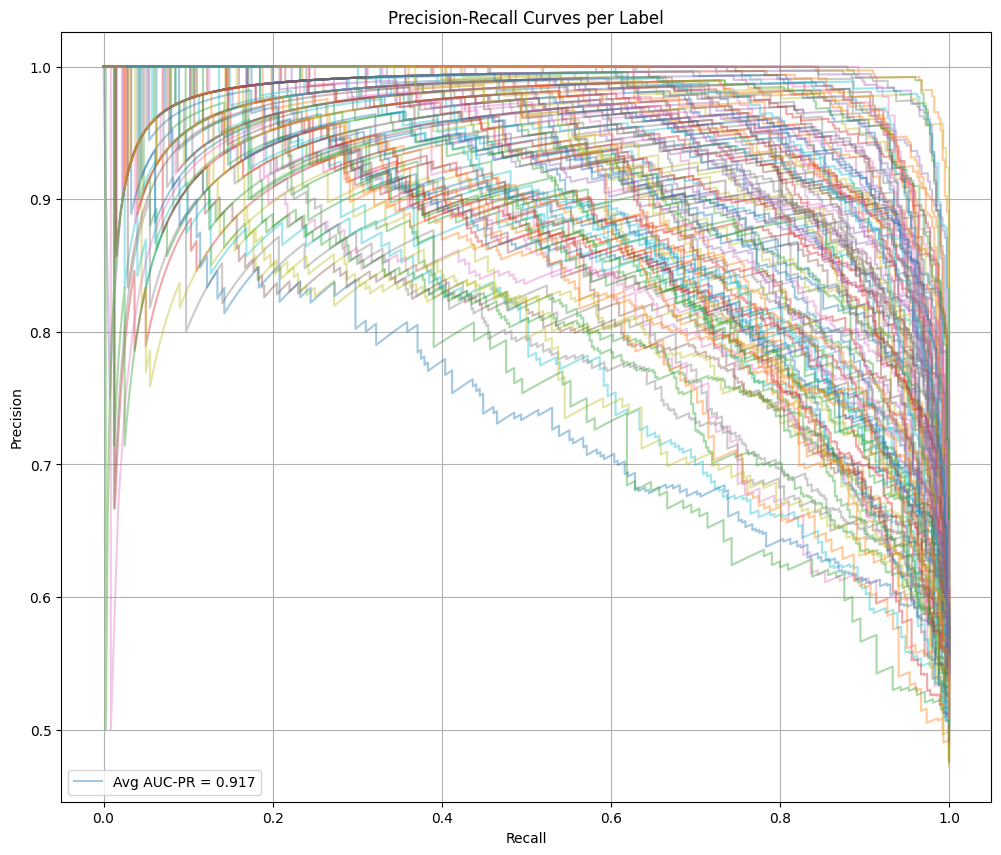

In [ ]:
pr_auc_dict = plot_precision_recall_curves(loaded_y_true, loaded_y_pred, label_names=protein_names, mask=loaded_y_mask)


In [ ]:
from sklearn.calibration import calibration_curve

def plot_calibration_curve(y_true, y_pred, mask=None, n_bins=20):
    """
    Plot calibration curve (reliability diagram) for all labels aggregated.
    """
    if mask is not None:
        valid = mask.astype(bool)
        y_true = y_true[valid]
        y_pred = y_pred[valid]
    else:
        y_true = y_true.flatten()
        y_pred = y_pred.flatten()

    prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=n_bins)

    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration Curve (All Labels Aggregated)")
    plt.grid(True)
    plt.legend()
    plt.show()


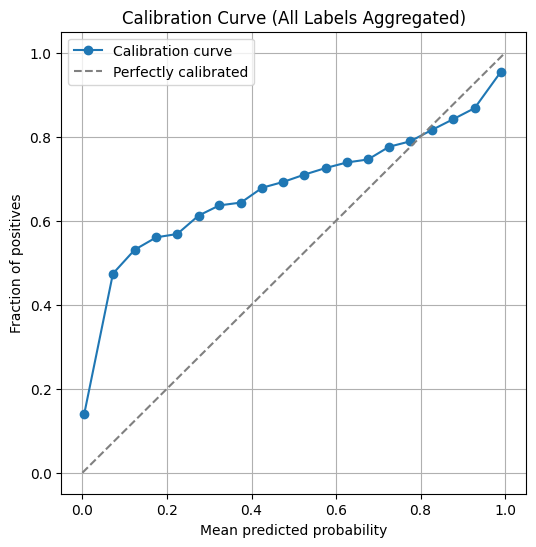

In [ ]:
plot_calibration_curve(loaded_y_true, loaded_y_pred, mask=loaded_y_mask)


In [ ]:
# Get metrics at two thresholds
rates_05, succ_05 = binding_rate_per_label(loaded_model, loaded_val_loader, device=device, threshold=0.5)
rates_08, succ_08 = binding_rate_per_label(loaded_model, loaded_val_loader, device=device, threshold=0.8)

sort_by = "rate" # rate/predictions

if sort_by == "rate":
    sorted_idx = np.argsort(rates_05)[::-1]
else:
    sorted_idx = np.argsort(succ_05)[::-1]

# Build table
rows = []
for i in sorted_idx:
    label = i + 1  # 0-based -> 1-based label
    name = Index_mapping.get(label, f"Protein_{label}")
    rows.append({
        "Protein": name,
        "Label": label,
        "Binding Rate (Thrsh=0.5)": f"{rates_05[i]:.6f}",
        "Binding Rate (Thrsh=0.8)": f"{rates_08[i]:.6f}",
        "Succesfull Predictions Ratio (Thrsh=0.5)": f"{succ_05[i]:.6f}" if not np.isnan(succ_05[i]) else "NaN",
        "Succesfull Predictions Ratio (Thrsh=0.8)": f"{succ_08[i]:.6f}" if not np.isnan(succ_08[i]) else "NaN",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))


 Protein  Label Binding Rate (Thrsh=0.5) Binding Rate (Thrsh=0.8) Succesfull Predictions Ratio (Thrsh=0.5) Succesfull Predictions Ratio (Thrsh=0.8)
    DDX6     22                 0.242026                 0.154106                                 0.765306                                 0.617347
  DROSHA     26                 0.238302                 0.175813                                 0.840000                                 0.755000
  RBFOX2     86                 0.234080                 0.169984                                 0.795000                                 0.715000
   DDX24     16                 0.227186                 0.151337                                 0.752500                                 0.597500
   SRSF1    101                 0.212180                 0.148472                                 0.772500                                 0.682500
   EIF3H     29                 0.210920                 0.129672                                 0.652500      

In [ ]:
@torch.no_grad()
def compute_codependence_matrix(model, dataloader, device="gpu", threshold=0.5, return_counts=False):
    """
    Computes a num_labels x num_labels matrix M where:
      - First we accumulate co-occurrence counts: C = sum_b (b^T @ b) over batches,
        where b is the binarized prediction matrix for a batch (thresholded).
      - Then we column-normalize by the diagonal: M[:, j] = C[:, j] / C[j, j].
        This yields M[j, j] = 1 (when C[j, j] > 0), and for i != j, M[i, j]
        is the fraction of times label i co-appears when label j appears.

    Returns:
      M: np.ndarray [L, L]  (float32), column-normalized co-dependence
      diag_counts: np.ndarray [L]      (int64), the diagonal counts (if return_counts=True)
    """
    model.eval()
    C = None
    L = None

    for batch in dataloader:
        # Supports datasets that yield (x, y, mask) or (x, y)
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        x = x.to(device, non_blocking=True)

        logits = model(x)
        probs = torch.sigmoid(logits)            # [B, L]
        preds = (probs >= threshold).to(torch.int64)  # [B, L]

        if L is None:
            L = preds.size(1)
        if C is None:
            C = np.zeros((L, L), dtype=np.int64)

        # Co-occurrence for the batch: preds^T @ preds
        # Move to CPU once per batch for efficiency
        P = preds.cpu().numpy().astype(np.int64)          # [B, L]
        C += P.T @ P                                      # [L, L]

    if C is None:
        raise ValueError("Dataloader produced no batches.")

    diag = C.diagonal().astype(np.float32)               # [L]
    M = C.astype(np.float32)

    # Column-normalize by the diagonal (avoid division by zero)
    for j in range(L):
        if diag[j] > 0:
            M[:, j] /= diag[j]
        else:
            M[:, j] = 0.0  # no positives for column j → set column to zeros

    if return_counts:
        return M, C, diag
    return M


In [ ]:
def plot_codependence_heatmap(M, Index_mapping, diag_counts=None, top_k=None, title="Co-dependence (squared scale)", power=None):
    """
    Plot a squared-scaled heatmap of the column-normalized co-dependence matrix M (shape [L, L]).

    Args:
        M: np.ndarray [L, L], M[:, j] = P(i | j)
        Index_mapping: dict {label_id (1..L) or negative ids: name}; we use positive ids 1..L
        diag_counts: np.ndarray [L] of raw diagonal counts (optional; for top_k selection)
        top_k: int or None. If provided, selects the top_k labels by diag_counts (or by column sums if diag_counts None).
        title: plot title
    """
    L = M.shape[0]
    assert M.shape[1] == L, "M must be square"

    # Choose which labels to show
    if top_k is not None and top_k < L:
        if diag_counts is not None:
            order = np.argsort(diag_counts)[::-1]
        else:
            order = np.argsort(M.sum(axis=0))[::-1]
        keep = order[:top_k]
        keep = np.sort(keep)
        M_show = M[np.ix_(keep, keep)]
        labels = [Index_mapping.get(i+1, str(i+1)) for i in keep]
    else:
        M_show = M
        labels = [Index_mapping.get(i+1, str(i+1)) for i in range(L)]

    # Apply square transform to emphasize values near 1
    if power is not None:
        M_sq = np.power(M_show, power)
    else:
        M_sq = M_show


    # Plot heatmap
    plt.figure(figsize=(max(6, 0.35*len(labels)), max(5, 0.35*len(labels))))
    im = plt.imshow(M_sq, aspect='auto', interpolation='nearest', cmap='viridis')
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Squared P(i | j)")

    plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=90)
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.title(title)
    plt.xlabel("Conditioned on protein j")
    plt.ylabel("Co-appearing protein i")
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram, fcluster
from scipy.spatial.distance import pdist
from scipy.ndimage import label

def split_cluster_by_brightness(M_ord, initial_thresh=0.6, brightness_thresh=0.3, min_block_size=2):
    """
    Recursively splits clusters based on brightness inside heatmap blocks.
    Ensures only meaningful, non-overlapping clusters are returned.
    """
    def recursive_split(indices, thresh):
        if len(indices) <= min_block_size:
            return [indices]

        submatrix = M_ord[np.ix_(indices, indices)]
        bright_mask = submatrix > brightness_thresh
        structure = np.ones((3, 3))
        labeled, num_features = label(bright_mask, structure=structure)

        if num_features <= 1:
            return [indices]

        # Reclustering
        try:
            D = pdist(submatrix + 1e-9, metric="cosine")
            Z_sub = linkage(D, method="average")
            clusters = fcluster(Z_sub, t=thresh * 0.8, criterion='distance')
        except:
            return [indices]  # fallback if linkage fails

        unique_clusters = np.unique(clusters)
        if len(unique_clusters) == 1:
            return [indices]

        results = []
        for uc in unique_clusters:
            group = [indices[i] for i in range(len(indices)) if clusters[i] == uc]
            if len(group) < min_block_size:
                continue
            results.extend(recursive_split(group, thresh * 0.8))
        return results

    # Initial global clustering
    D = pdist(M_ord + 1e-9, metric="cosine")
    Z = linkage(D, method="average")
    cluster_ids = fcluster(Z, t=initial_thresh, criterion='distance')

    all_clusters = []
    for cluster_id in np.unique(cluster_ids):
        members = np.where(cluster_ids == cluster_id)[0]
        if len(members) < min_block_size:
            continue
        all_clusters.extend(recursive_split(members.tolist(), initial_thresh))

    # Overlap filtering: keep only the smallest non-contained clusters
    final_clusters = []
    used = np.zeros(len(M_ord), dtype=bool)
    for cluster in sorted(all_clusters, key=lambda x: len(x)):
        if any(used[i] for i in cluster):
            continue
        final_clusters.append(cluster)
        for i in cluster:
            used[i] = True

    return final_clusters


def cluster_and_plot_heatmap(M, Index_mapping, top_k=None, title="Co-dependence (clustered)", power=None, plot_squares=True, plot_dendrogram=False):
    """
    Clusters and visualizes the co-dependence matrix M.
    Adds recursive visual detection of bright blocks (adaptive to clustering).
    Returns:
        M_ord: clustered matrix
        labels_ord: reordered protein names
        cluster_dict: {
            clusterX: {
                'proteins': [...],
                'cohesion': float,
                'brightness': float,
                'strength': float
            }
        }
    """
    L = M.shape[0]
    assert M.shape[1] == L, "M must be square"

    if top_k is not None and top_k < L:
        order_by_mass = np.argsort(M.sum(axis=0))[::-1][:top_k]
        order_by_mass = np.sort(order_by_mass)
        M_use = M[np.ix_(order_by_mass, order_by_mass)]
        labels = [Index_mapping.get(i+1, str(i+1)) for i in order_by_mass]
    else:
        M_use = M
        labels = [Index_mapping.get(i+1, str(i+1)) for i in range(L)]

    # Clustering
    S = 0.5 * (M_use + M_use.T) + 1e-9
    D = pdist(S, metric="cosine")
    Z = linkage(D, method="average")
    leaves = leaves_list(Z)

    M_ord = M_use[leaves][:, leaves]
    labels_ord = [labels[i] for i in leaves]

    # Visual block detection
    clusters = split_cluster_by_brightness(M_ord, initial_thresh=0.6)
    cluster_dict = {}

    # Sort clusters by first index
    clusters_sorted = sorted(clusters, key=lambda c: min(c))
    flat_indices = [i for cluster in clusters_sorted for i in cluster]

    # Reorder matrix and labels
    M_ord = M_ord[np.ix_(flat_indices, flat_indices)]
    labels_ord = [labels_ord[i] for i in flat_indices]

    # Build cluster dictionary with strength
    for i, cluster in enumerate(clusters_sorted):
        cluster_name = f"cluster{i+1}"
        cluster_indices = [j for j in range(len(labels_ord)) if flat_indices[j] in cluster]
        proteins = [labels_ord[j] for j in cluster_indices]

        # Compute cohesion and brightness
        if len(cluster_indices) > 1:
            subM = M_ord[np.ix_(cluster_indices, cluster_indices)]
            subS = 0.5 * (subM + subM.T)
            cohesion = 1 - np.mean(pdist(subS + 1e-9, metric='cosine'))
            brightness = np.mean(subM)
        else:
            cohesion = 1.0
            brightness = 0.0
        strength = 0.5 * cohesion + 0.5 * brightness

        cluster_dict[cluster_name] = {
            "proteins": proteins,
            "cohesion": cohesion,
            "brightness": brightness,
            "strength": strength
        }

    # Plot reordered heatmap
    if power is not None:
        M_plot = np.power(M_ord, power)
        cbar_label = f"P(i|j)^{power}"
    else:
        M_plot = M_ord
        cbar_label = "P(i|j)"

    plt.figure(figsize=(max(6, 0.35*len(labels_ord)), max(5, 0.35*len(labels_ord))))
    im = plt.imshow(M_plot, aspect='auto', interpolation='nearest', cmap='viridis', vmin=0.0, vmax=1.0)
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)
    plt.xticks(range(len(labels_ord)), labels_ord, rotation=90)
    plt.yticks(range(len(labels_ord)), labels_ord)
    plt.title(title)
    plt.xlabel("Conditioned on protein j (clustered by bright blocks)")
    plt.ylabel("Co-appearing protein i (clustered by bright blocks)")

    for cluster in clusters_sorted:
        if len(cluster) < 2:
            continue
        if plot_squares:
            new_pos = [flat_indices.index(i) for i in cluster]
            min_i, max_i = min(new_pos), max(new_pos)
            size = max_i - min_i + 1
            rect = plt.Rectangle((min_i - 0.5, min_i - 0.5), size, size,
                                edgecolor='cyan', facecolor='none', linewidth=5)
            plt.gca().add_patch(rect)

    plt.tight_layout()
    plt.show()

    # Dendrogram
    if plot_dendrogram:
        plt.figure(figsize=(12, 6), dpi=300)
        dendrogram(Z, labels=labels, leaf_rotation=90)
        plt.title("Protein Clustering Dendrogram")
        plt.xlabel("Proteins")
        plt.ylabel("Distance")
        plt.tight_layout()
        plt.show()

    return M_ord, labels_ord, cluster_dict


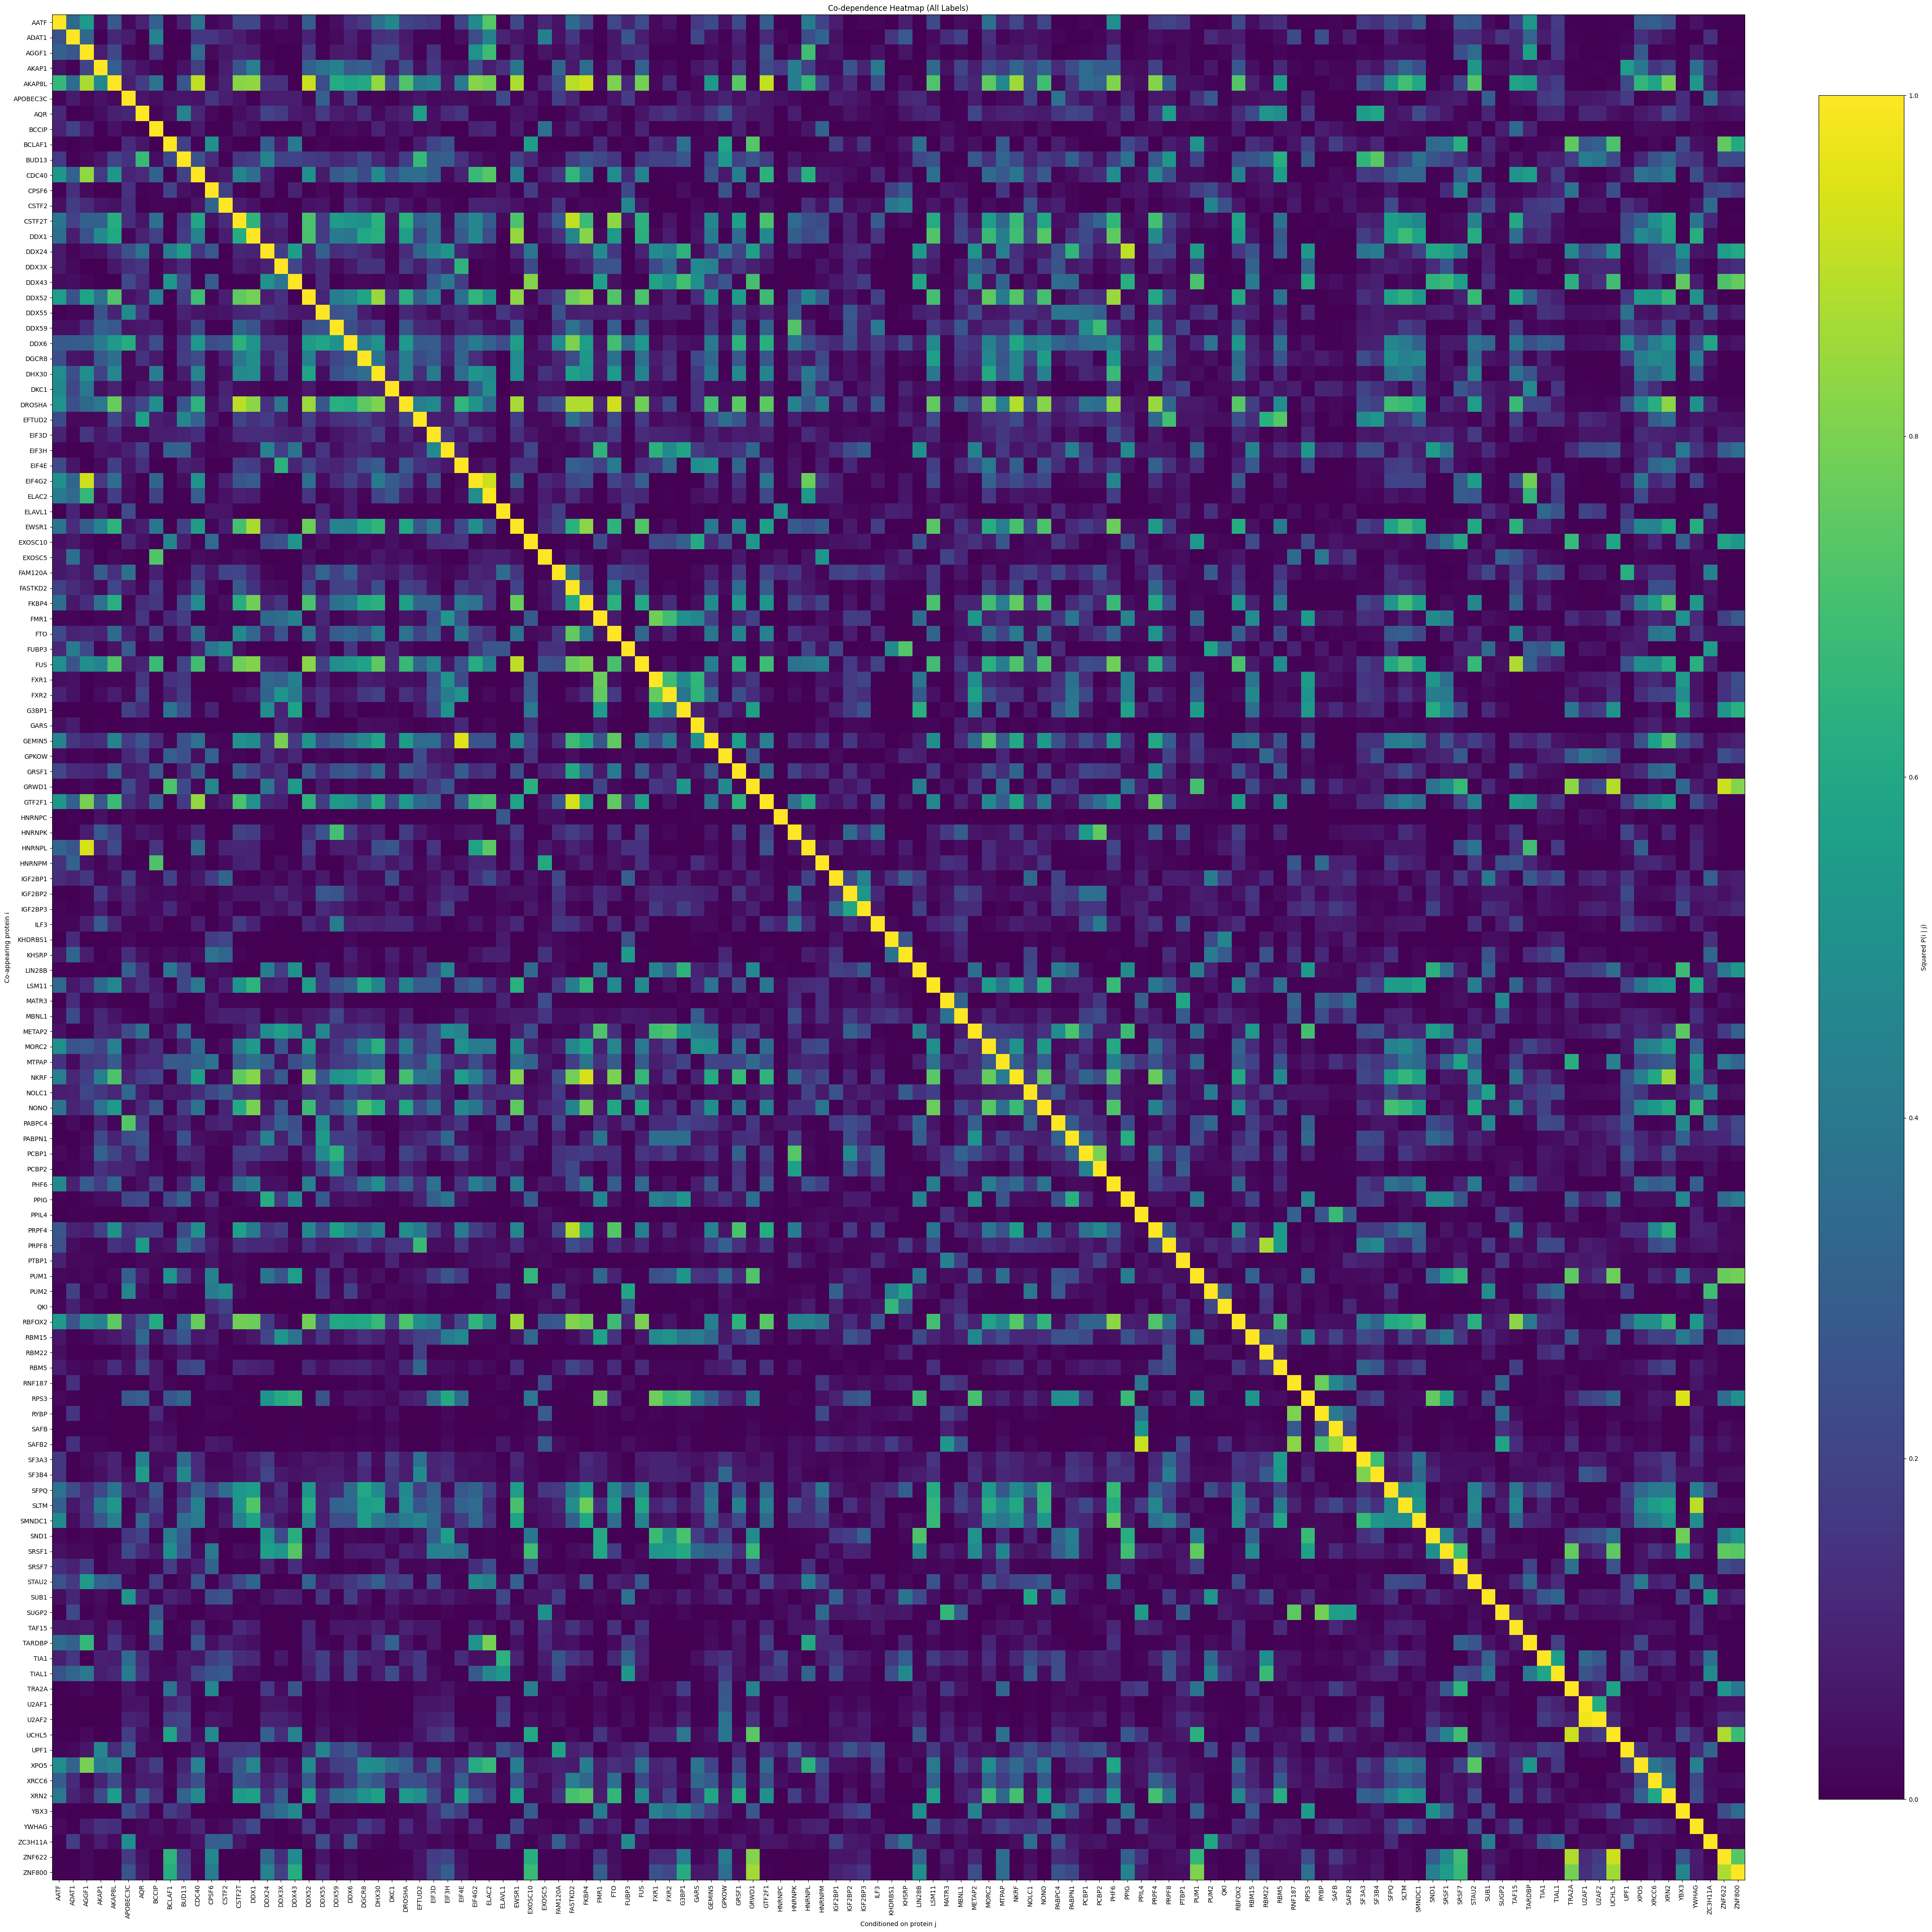

In [ ]:
# Compute (as you already do)
M, C_raw, diag_counts = compute_codependence_matrix(
    loaded_model, loaded_val_loader, device=device, threshold=0.8, return_counts=True
)

# 1) Full heatmap (all 122x122)
plot_codependence_heatmap(M, Index_mapping, diag_counts=diag_counts, top_k=None,
                          title="Co-dependence Heatmap (All Labels)", power=None)

# 2) Or a focused view: top-30 most frequent positives by diag count
# plot_codependence_heatmap(M, Index_mapping, diag_counts=diag_counts, top_k=30,
#                           title="Co-dependence Heatmap (Top 30 by prevalence)")


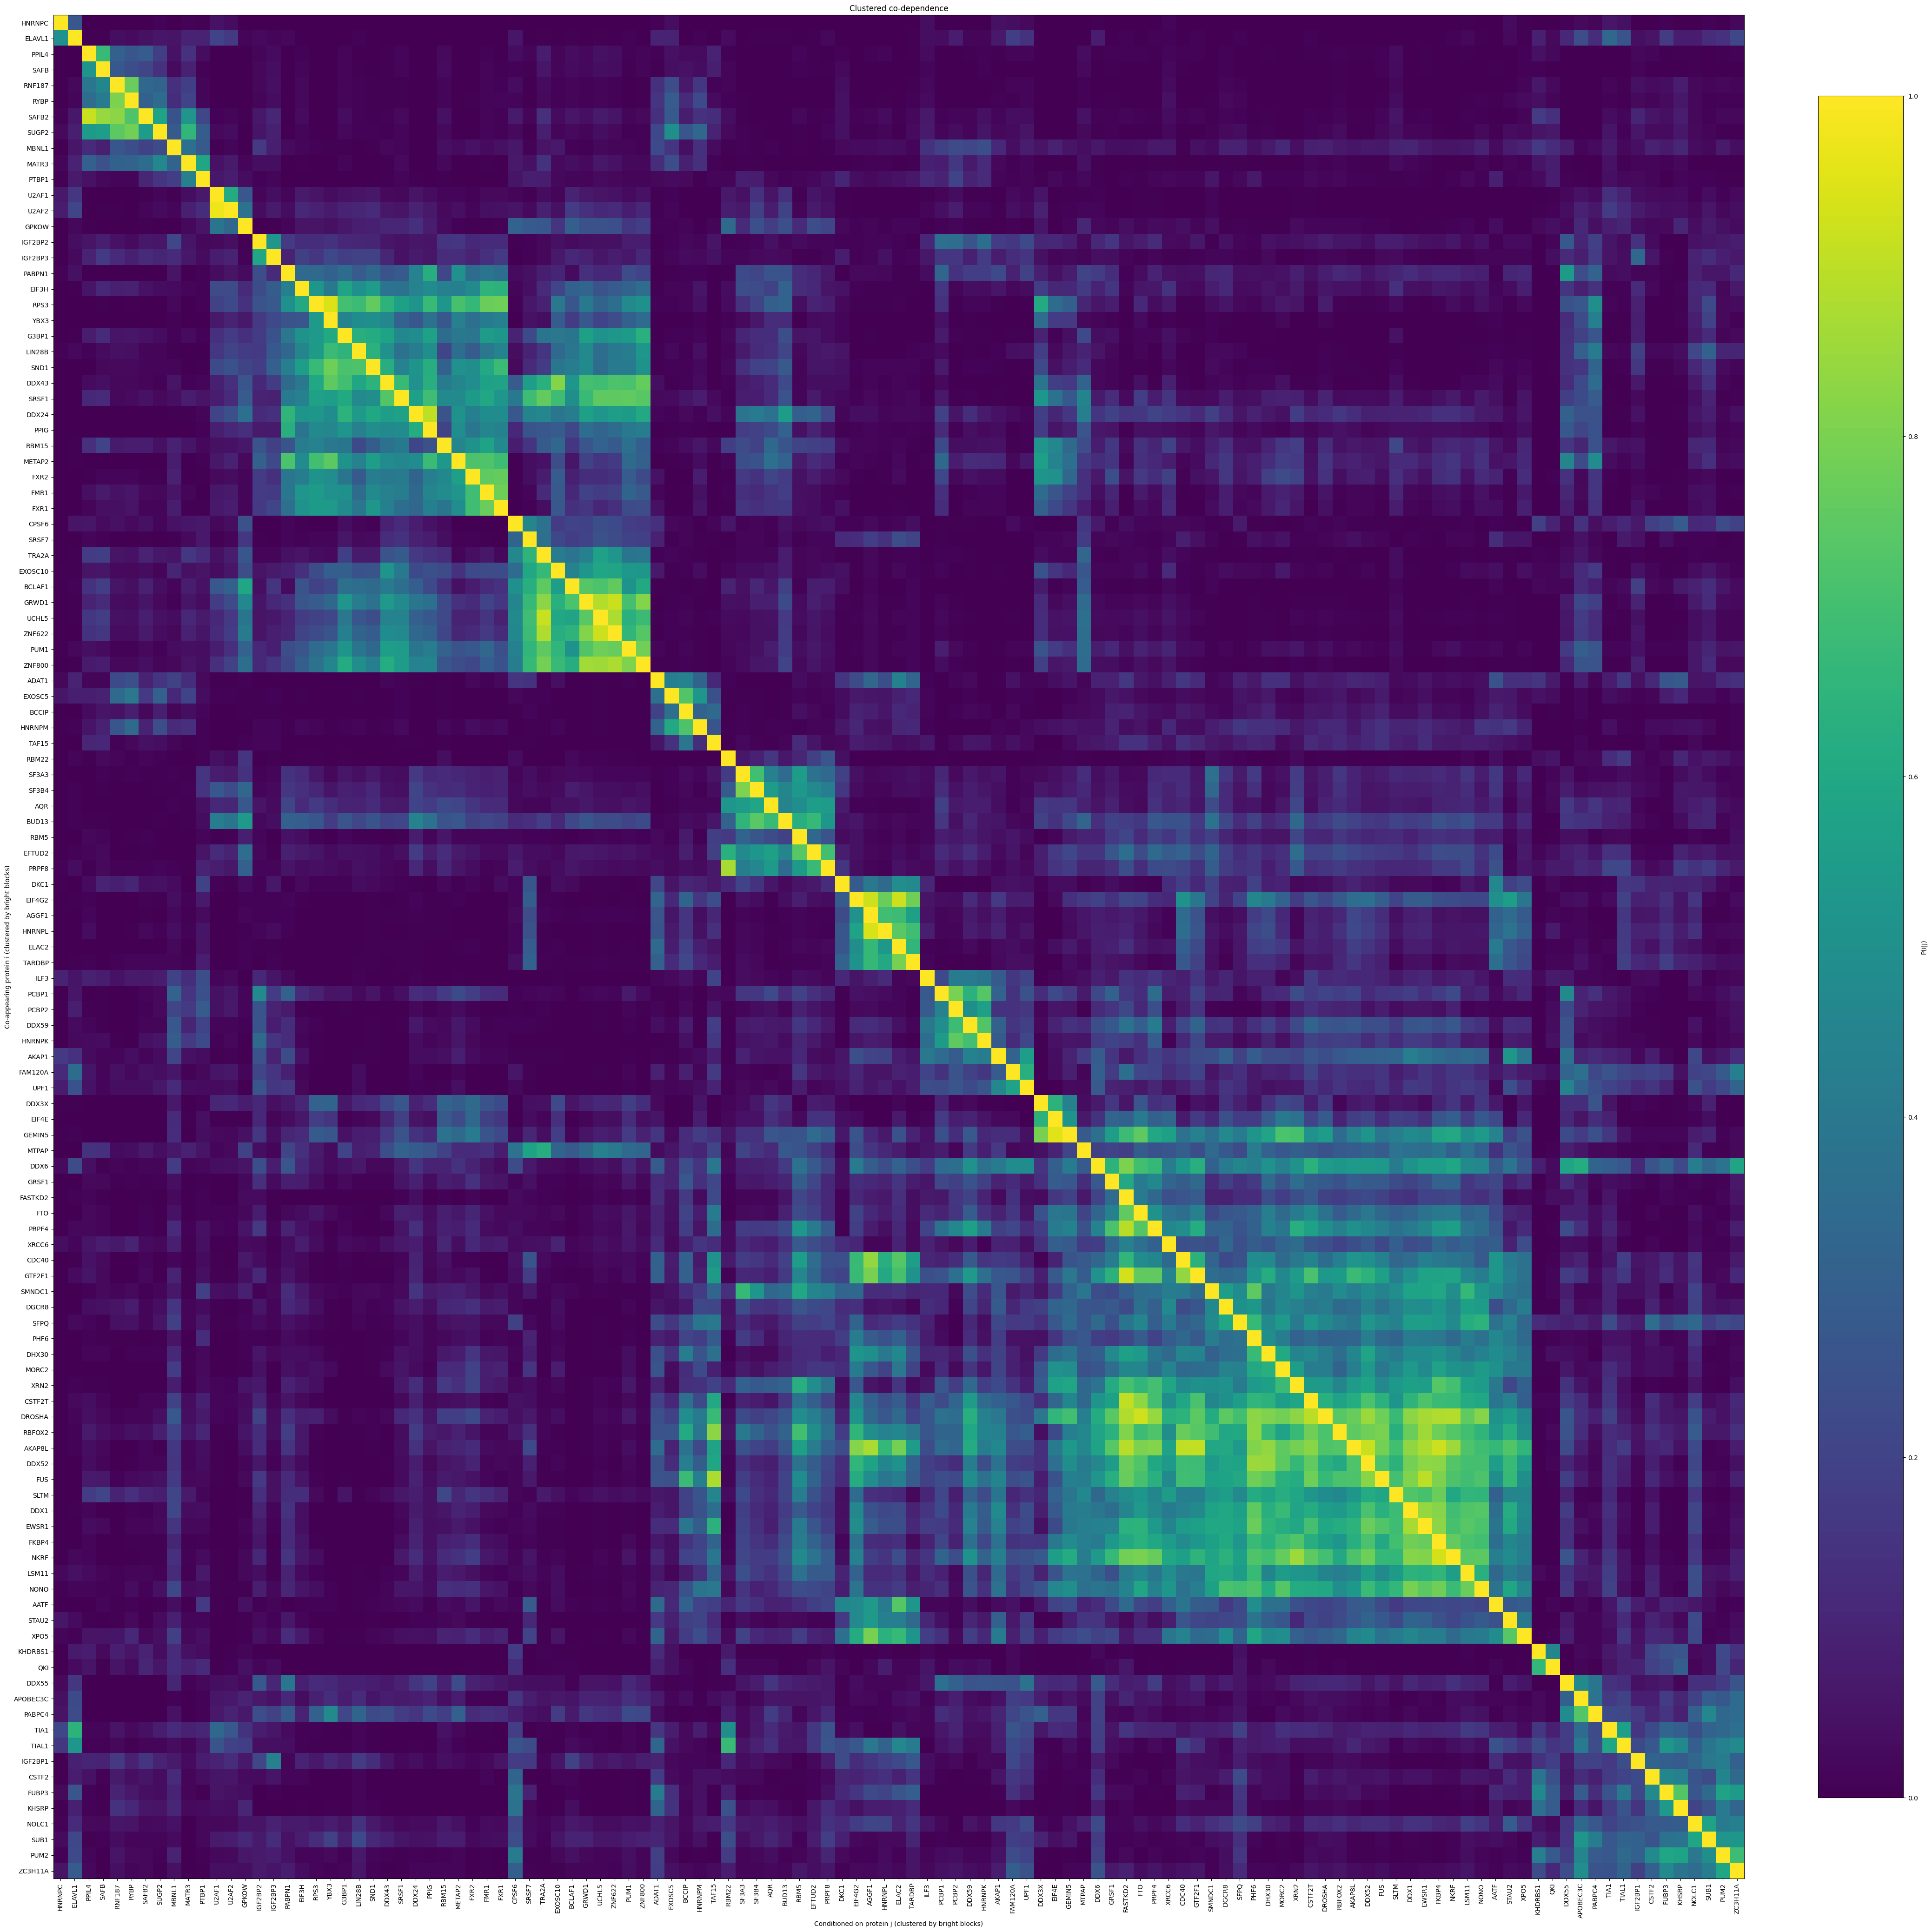

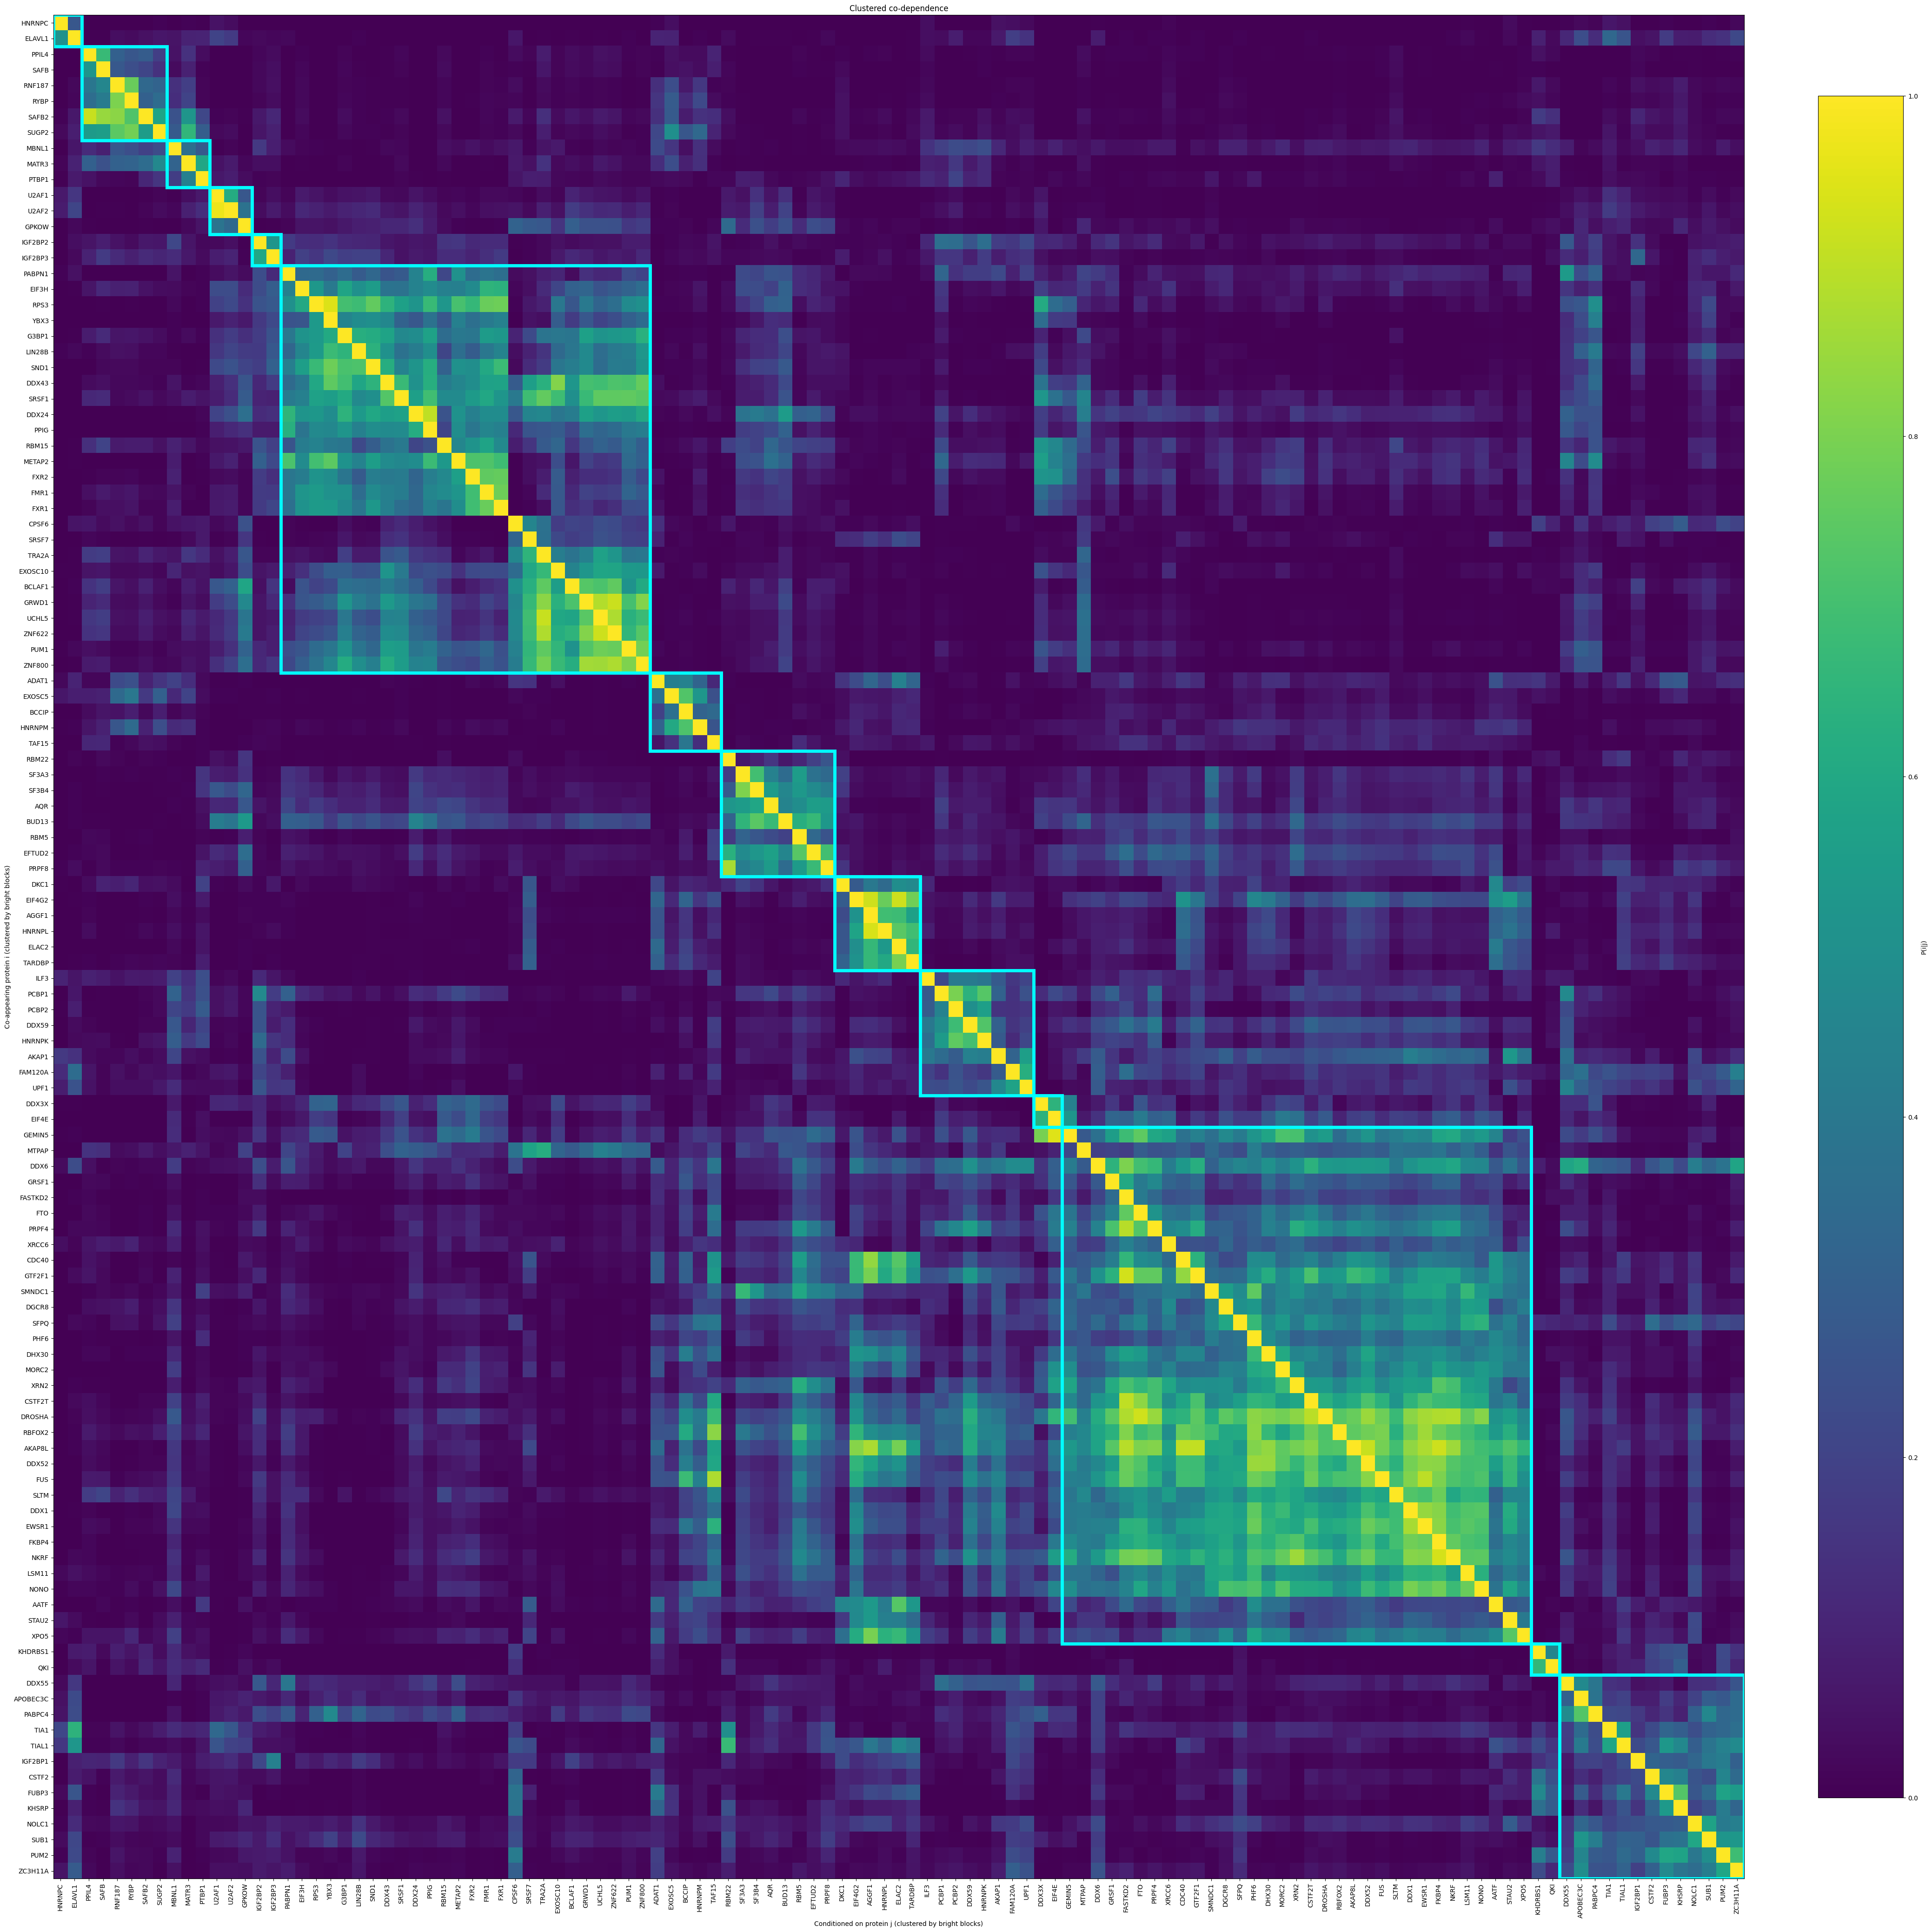

In [ ]:
# Full clustered view with the x^2 emphasis you liked:
M_ord, labels_ord, cluster_dict = cluster_and_plot_heatmap(M, Index_mapping, top_k=None, power=None, title="Clustered co-dependence", plot_squares=False)
M_ord, labels_ord, cluster_dict = cluster_and_plot_heatmap(M, Index_mapping, top_k=None, power=None, title="Clustered co-dependence", plot_squares=True)


In [ ]:
print(np.shape(M))
print(np.shape(M_ord))

(122, 122)
(119, 119)


In [ ]:
import json

def print_cluster_dict(cluster_dict):
    for cname, info in cluster_dict.items():
        proteins_str = ", ".join(info["proteins"])
        cohesion = round(float(info["cohesion"]), 3)
        brightness = round(float(info["brightness"]), 3)
        strength = round(float(info["strength"]), 3)
        print(f'{cname}: {{')
        print(f'  "proteins": [{proteins_str}],')
        print(f'  "cohesion": {cohesion},')
        print(f'  "brightness": {brightness},')
        print(f'  "strength": {strength}')
        print("}")

print_cluster_dict(cluster_dict)

cluster1: {
  "proteins": [HNRNPC, ELAVL1],
  "cohesion": 0.675,
  "brightness": 0.694,
  "strength": 0.685
}
cluster2: {
  "proteins": [PPIL4, SAFB, RNF187, RYBP, SAFB2, SUGP2],
  "cohesion": 0.844,
  "brightness": 0.575,
  "strength": 0.71
}
cluster3: {
  "proteins": [MBNL1, MATR3, PTBP1],
  "cohesion": 0.656,
  "brightness": 0.575,
  "strength": 0.615
}
cluster4: {
  "proteins": [U2AF1, U2AF2, GPKOW],
  "cohesion": 0.76,
  "brightness": 0.663,
  "strength": 0.712
}
cluster5: {
  "proteins": [IGF2BP2, IGF2BP3],
  "cohesion": 0.849,
  "brightness": 0.778,
  "strength": 0.814
}
cluster6: {
  "proteins": [PABPN1, EIF3H, RPS3, YBX3, G3BP1, LIN28B, SND1, DDX43, SRSF1, DDX24, PPIG, RBM15, METAP2, FXR2, FMR1, FXR1, CPSF6, SRSF7, TRA2A, EXOSC10, BCLAF1, GRWD1, UCHL5, ZNF622, PUM1, ZNF800],
  "cohesion": 0.779,
  "brightness": 0.415,
  "strength": 0.597
}
cluster7: {
  "proteins": [ADAT1, EXOSC5, BCCIP, HNRNPM, TAF15],
  "cohesion": 0.669,
  "brightness": 0.481,
  "strength": 0.575
}
cluster8

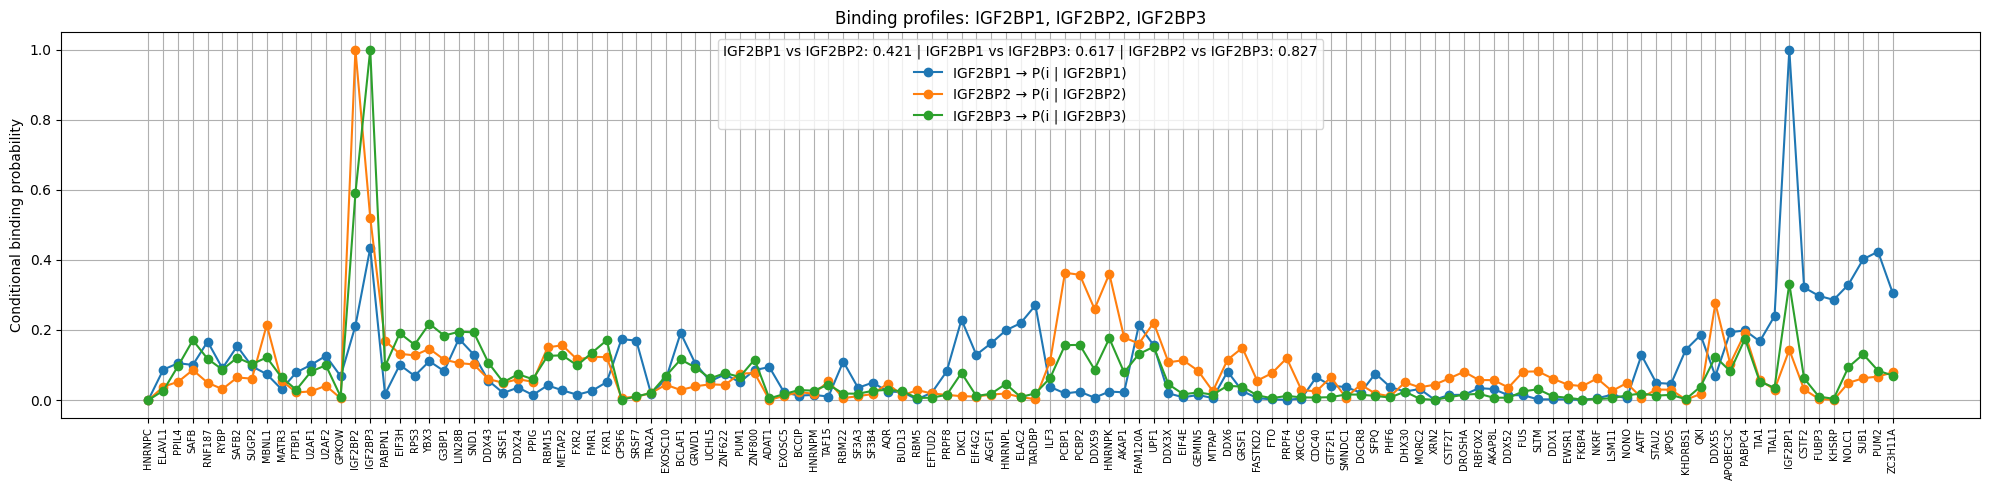

In [ ]:
def plot_binding_profiles_multiple(M_ord, labels_ord, Class_mapping, protein_names):
    """
    Plots binding profiles for multiple proteins and reports cosine similarities.
    """
    clustered_label_to_index = {name: i for i, name in enumerate(labels_ord)}
    x_labels = list(clustered_label_to_index.keys())
    profiles = {}

    plt.figure(figsize=(max(20, 1.2 * len(protein_names)), 5))

    for name in protein_names:
        if name not in Class_mapping:
            print(f"Warning: '{name}' not found in Class_mapping.")
            continue

        orig_index = abs(Class_mapping[name]) - 1
        orig_name = next((k for k, v in Class_mapping.items() if abs(v) - 1 == orig_index and not k.startswith("NEG_")), None)

        if orig_name not in clustered_label_to_index:
            print(f"Warning: '{name}' (original name: {orig_name}) not found in clustered labels.")
            continue

        clustered_idx = clustered_label_to_index[orig_name]
        profile = M_ord[clustered_idx, :]
        profiles[name] = profile  # Save for similarity calculation

        plt.plot(profile, label=f"{name} → P(i | {name})", marker='o')

    # Print pairwise cosine similarities (optional: show in title/legend)
    sim_text = ""
    if len(profiles) >= 2:
        keys = list(profiles.keys())
        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                p1, p2 = keys[i], keys[j]
                sim = 1 - cosine(profiles[p1], profiles[p2])
                sim_text += f"{p1} vs {p2}: {sim:.3f} | "

    plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=90, fontsize=7)
    plt.ylabel("Conditional binding probability")
    plt.title(f"Binding profiles: {', '.join(protein_names)}")
    plt.legend(title=sim_text.strip(" |"))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


proteins = ["IGF2BP1", "IGF2BP2", "IGF2BP3"]
plot_binding_profiles_multiple(M_ord, labels_ord, Class_mapping, proteins)


In [ ]:
# _, _, _ = cluster_and_plot_heatmap(M, Index_mapping, top_k=40, power=2, title="Top-40 clustered (squared)")

In [ ]:
import numpy as np
import pandas as pd

def top_k_cobinders(M, Index_mapping, k=5, min_diag=1, diag_counts=None, labels_ord=None):
    """
    Returns a DataFrame with a CONSISTENT schema:
    ['anchor_label','anchor_name','partner_label','partner_name','P(i|j)','rank']

    - M: [L,L] column-normalized P(i|j). If this is clustered/reordered (M_ord),
         pass the matching label order via labels_ord (list of names).
    - Index_mapping: {1..L -> name} (positive IDs only).
    - k: top-k partners per anchor.
    - min_diag: require at least this many positives for the anchor
                (if diag_counts provided; diag_counts must already match M’s order).
    - diag_counts: optional [L] prevalence per anchor (already reordered if M is).
    - labels_ord: optional list of label NAMES matching rows/cols of M (clustered order).
                  If None, labels resolved by ids (1..L) with Index_mapping.
    """
    L = M.shape[0]
    assert M.shape[1] == L, "M must be square"

    # Build inverse mapping name -> id (only positive ids)
    inv_map = {v: k for k, v in Index_mapping.items() if isinstance(k, int) and k > 0}

    records = []

    for j in range(L):
        if diag_counts is not None and diag_counts[j] < min_diag:
            continue

        col = M[:, j].copy()
        col[j] = -1.0  # exclude self
        top_idx = np.argsort(col)[::-1][:k]

        # Resolve anchor id/name
        if labels_ord is not None:
            anchor_name = labels_ord[j]
            anchor_label = inv_map.get(anchor_name, None)
        else:
            anchor_label = j + 1
            anchor_name = Index_mapping.get(anchor_label, str(anchor_label))

        for rank, i in enumerate(top_idx, start=1):
            if labels_ord is not None:
                partner_name = labels_ord[i]
                partner_label = inv_map.get(partner_name, None)
            else:
                partner_label = i + 1
                partner_name = Index_mapping.get(partner_label, str(partner_label))

            records.append({
                "anchor_label": anchor_label,
                "anchor_name": anchor_name,
                "partner_label": partner_label,
                "partner_name": partner_name,
                "P(i|j)": float(M[i, j]),
                "rank": rank
            })

    return pd.DataFrame(records).sort_values(["anchor_label", "rank"]).reset_index(drop=True)


In [ ]:
df_top = top_k_cobinders(M_ord, Index_mapping, k=10, min_diag=1, diag_counts=None, labels_ord=labels_ord)
# Inspect a specific anchor:
df_top[df_top["anchor_label"] == 85].head(10)
# Or save:
# df_top.to_csv("top_cobinders.csv", index=False)

,anchor_label,anchor_name,partner_label,partner_name,P(i|j),rank
820,85,QKI,61,KHDRBS1,0.456836,1
821,85,QKI,62,KHSRP,0.289781,2
822,85,QKI,42,FUBP3,0.289547,3
823,85,QKI,84,PUM2,0.284414,4
824,85,QKI,13,CSTF2,0.245917,5
825,85,QKI,57,IGF2BP1,0.185488,6
826,85,QKI,109,TIAL1,0.155156,7
827,85,QKI,94,SAFB2,0.136258,8
828,85,QKI,66,MBNL1,0.125292,9
829,85,QKI,120,ZC3H11A,0.115259,10


In [ ]:
def plot_directionality(M, Index_mapping, top_k=None, title="Directionality M - Mᵀ", labels_ord=None):
    """
    Plots A = M - M^T with correct labels. If labels_ord is provided (names in M’s order),
    it’s used directly; otherwise uses Index_mapping and optional top_k selection.
    """
    L = M.shape[0]

    if labels_ord is not None:
        M_use = M
        labels = list(labels_ord)
    else:
        if top_k is not None and top_k < L:
            order_by_mass = np.argsort(M.sum(axis=0))[::-1][:top_k]
            order_by_mass = np.sort(order_by_mass)
            M_use = M[np.ix_(order_by_mass, order_by_mass)]
            labels = [Index_mapping.get(i+1, str(i+1)) for i in order_by_mass]
        else:
            M_use = M
            labels = [Index_mapping.get(i+1, str(i+1)) for i in range(L)]

    A = M_use - M_use.T
    vmax = np.max(np.abs(A)) + 1e-9

    plt.figure(figsize=(max(6, 0.35*len(labels)), max(5, 0.35*len(labels))))
    im = plt.imshow(A, aspect='auto', interpolation='nearest', cmap='bwr', vmin=-vmax, vmax=vmax)
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("P(i|j) - P(j|i)")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.xlabel("j")
    plt.ylabel("i")
    plt.tight_layout()
    plt.show()


In [ ]:
def most_asymmetric_pairs(M, Index_mapping, top_n=20, labels_ord=None):
    """
    Returns the top-N asymmetric pairs by |M[i,j] - M[j,i]|.
    If labels_ord is provided (list of names matching the rows/cols of M),
    those names are used; we also attempt to map them back to label ids via Index_mapping.

    Output columns (always the same):
      - i_label, i_name, j_label, j_name, P(i|j), P(j|i), diff, abs_diff
    """
    L = M.shape[0]
    assert M.shape[1] == L, "M must be square"

    # Build inverse name->id map for positive ids only
    inv_map = {v: k for k, v in Index_mapping.items() if isinstance(k, int) and k > 0}

    pairs = []
    for i in range(L):
        for j in range(i+1, L):
            pij = float(M[i, j])
            pji = float(M[j, i])
            diff = pij - pji
            absd = abs(diff)

            if labels_ord is not None:
                i_name = labels_ord[i]
                j_name = labels_ord[j]
                i_label = inv_map.get(i_name, None)
                j_label = inv_map.get(j_name, None)
            else:
                i_label = i + 1
                j_label = j + 1
                i_name  = Index_mapping.get(i_label, str(i_label))
                j_name  = Index_mapping.get(j_label, str(j_label))

            pairs.append({
                "i_label": i_label,
                "i_name": i_name,
                "j_label": j_label,
                "j_name": j_name,
                "P(i|j)": pij,
                "P(j|i)": pji,
                "diff": diff,
                "abs_diff": absd
            })

    df = pd.DataFrame(pairs).sort_values("abs_diff", ascending=False).head(top_n)
    return df.reset_index(drop=True)

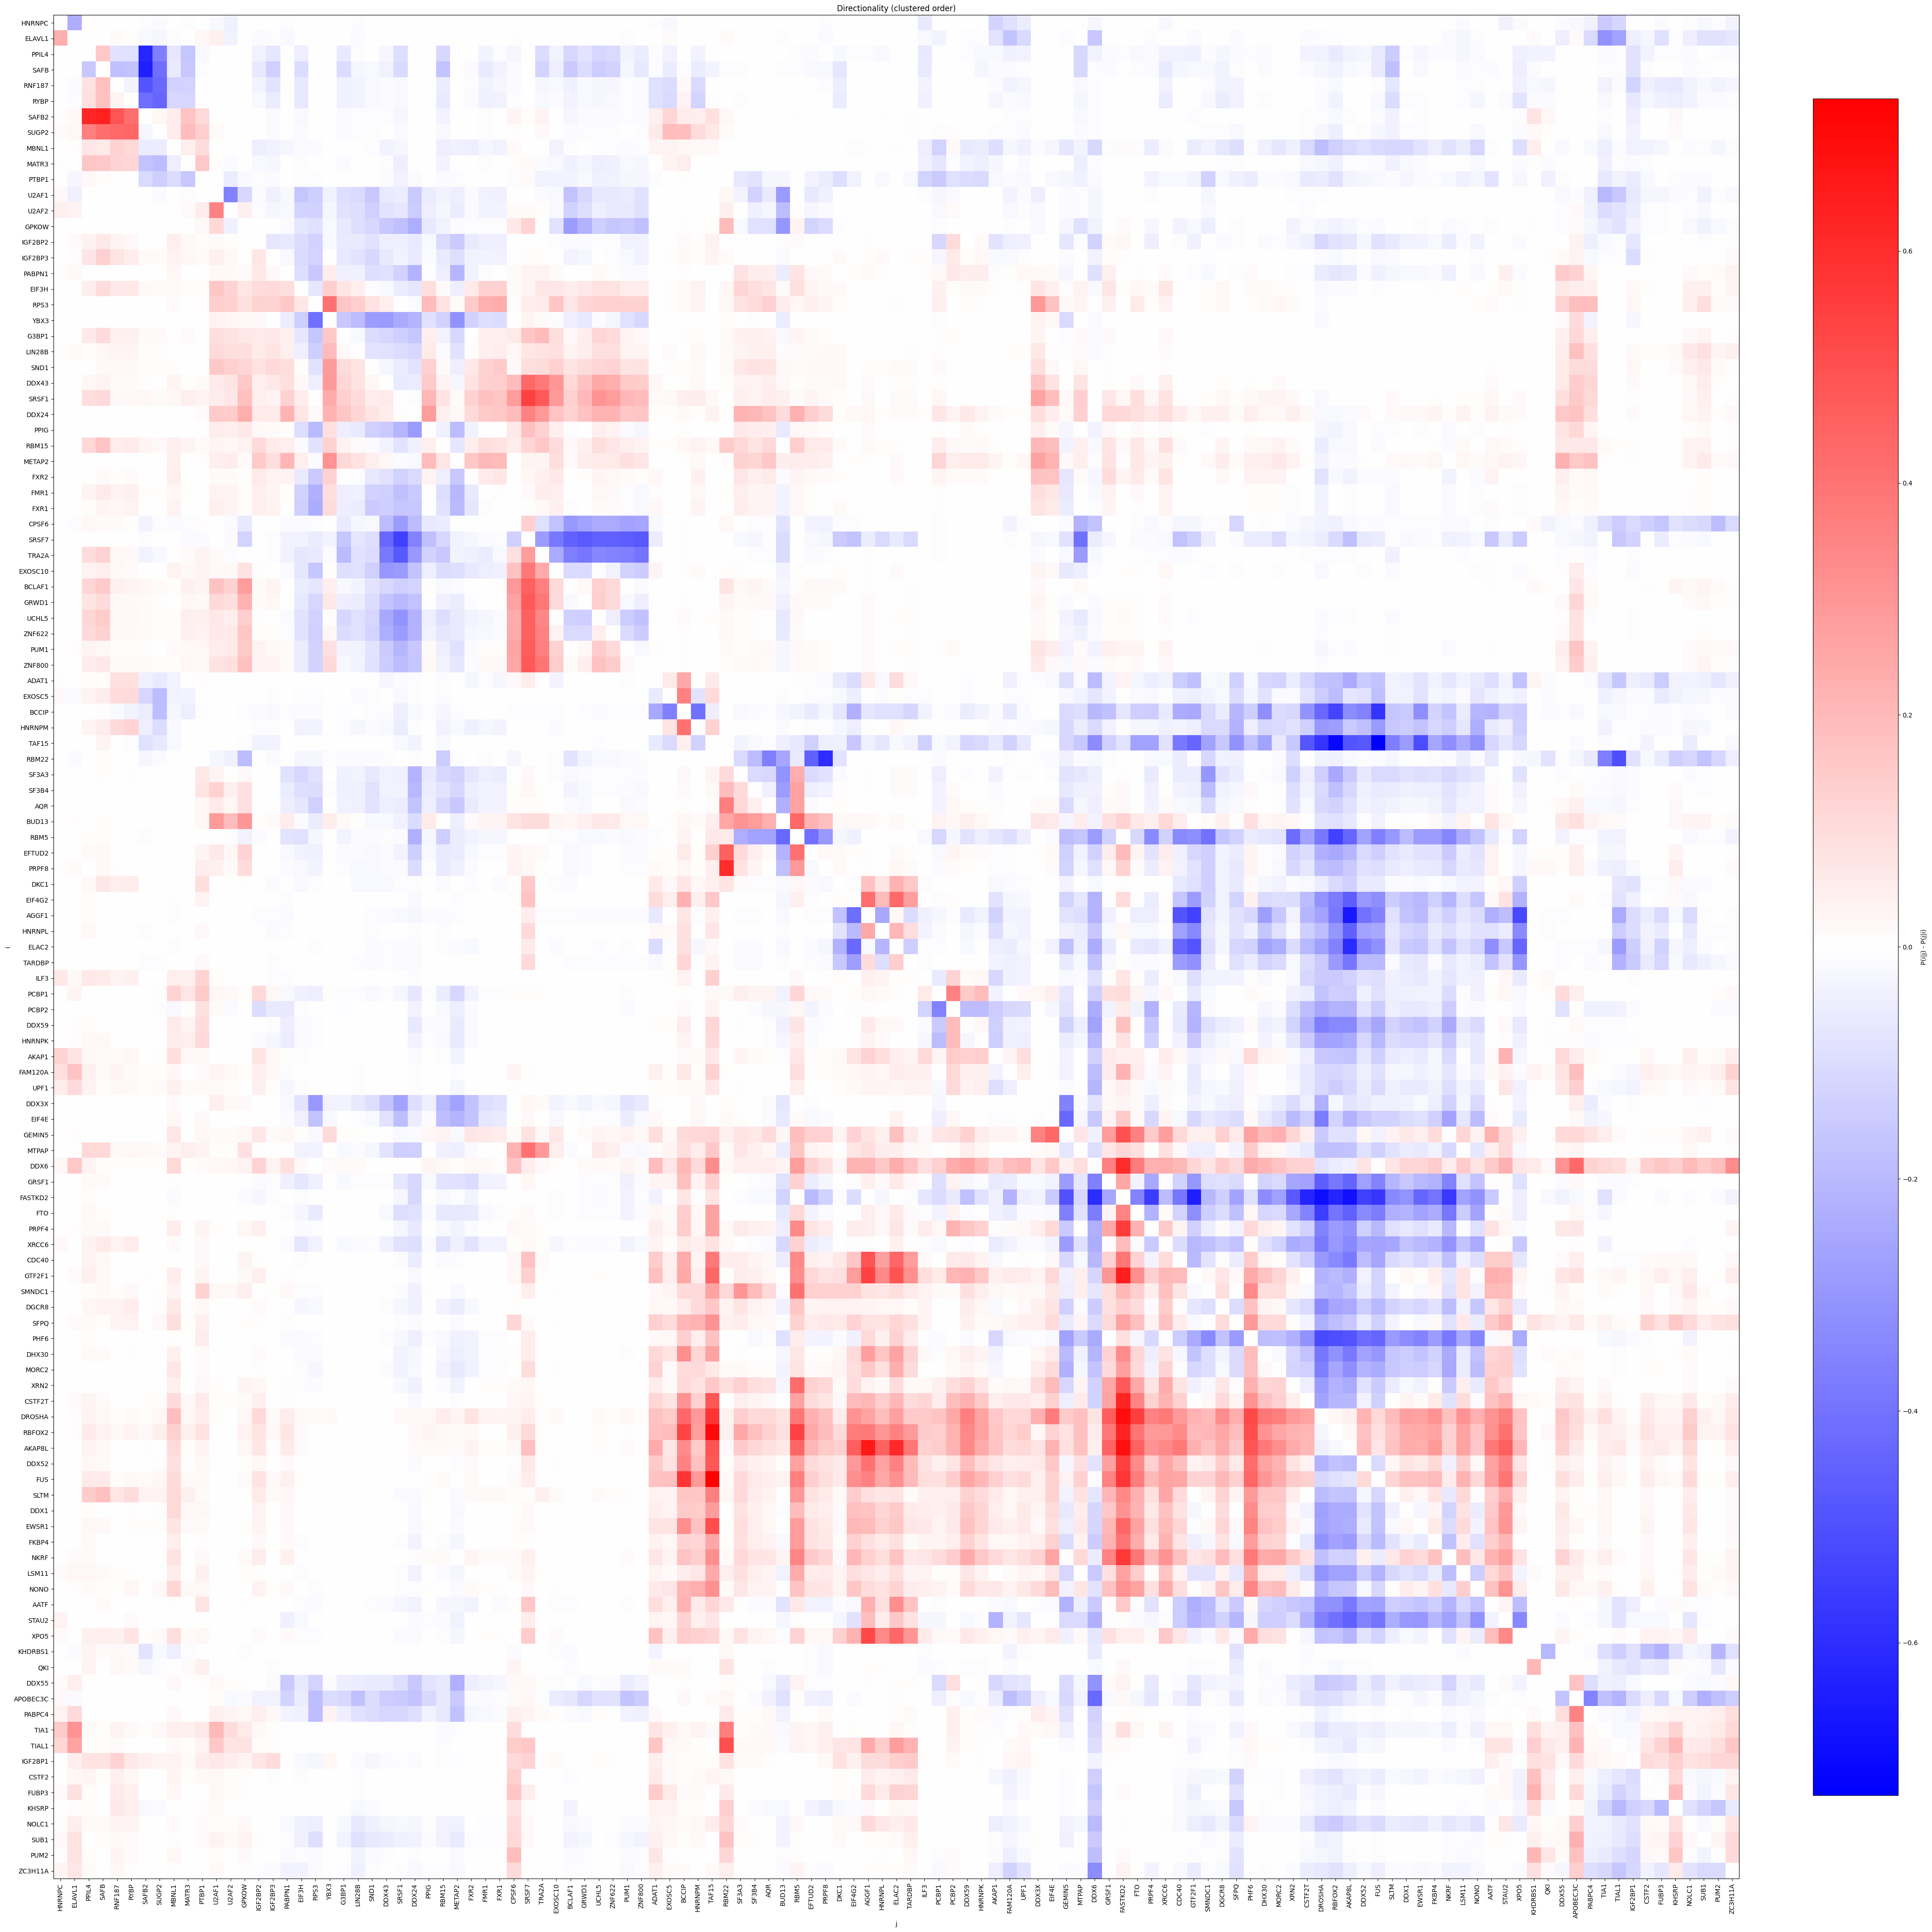

,i_label,i_name,j_label,j_name,P(i|j),P(j|i),diff,abs_diff
0,43,FUS,106,TAF15,0.876249,0.144690,0.731559,0.731559
1,86,RBFOX2,106,TAF15,0.827414,0.121427,0.705987,0.705987
2,26,DROSHA,38,FASTKD2,0.881380,0.193071,0.688309,0.688309
3,5,AKAP8L,38,FASTKD2,0.892523,0.207383,0.685140,0.685140
4,3,AGGF1,5,AKAP8L,0.211476,0.874309,-0.662834,0.662834
5,38,FASTKD2,52,GTF2F1,0.287443,0.930625,-0.643182,0.643182
6,93,SAFB,94,SAFB2,0.207836,0.845220,-0.637384,0.637384
7,38,FASTKD2,86,RBFOX2,0.184054,0.812365,-0.628311,0.628311
8,14,CSTF2T,38,FASTKD2,0.905464,0.279702,0.625761,0.625761
9,79,PPIL4,94,SAFB2,0.292164,0.914720,-0.622555,0.622555


In [ ]:
# Heatmap of asymmetry
plot_directionality(M_ord, Index_mapping, title="Directionality (clustered order)", labels_ord=labels_ord)

# List the most directional pairs
df_asym = most_asymmetric_pairs(M, Index_mapping, top_n=30)
# df_asym.to_csv("most_asymmetric_pairs.csv", index=False)
df_asym.head(20)
